## 메인 퀘스트1 : 스페이스 타이타닉이 사고후 발생한 시간 이동자를 찾아라
 분류문제 데이터셋 파악후 EDA 과정을 거쳐 모델을 학습시키고 진짜 양성자를 예측해보자.
- 5시 반까지 제출 1점
- 보고서 작성 1점
- EDA과정중 데이터 전처리와 시각화 우수시 1점
- 캐글 점수 0.805 이상 달성시 1점
- 모델 학습 성공과 결과 예측 인사이트 도출 1점(스도쿠 같은 느낌이라 하심)

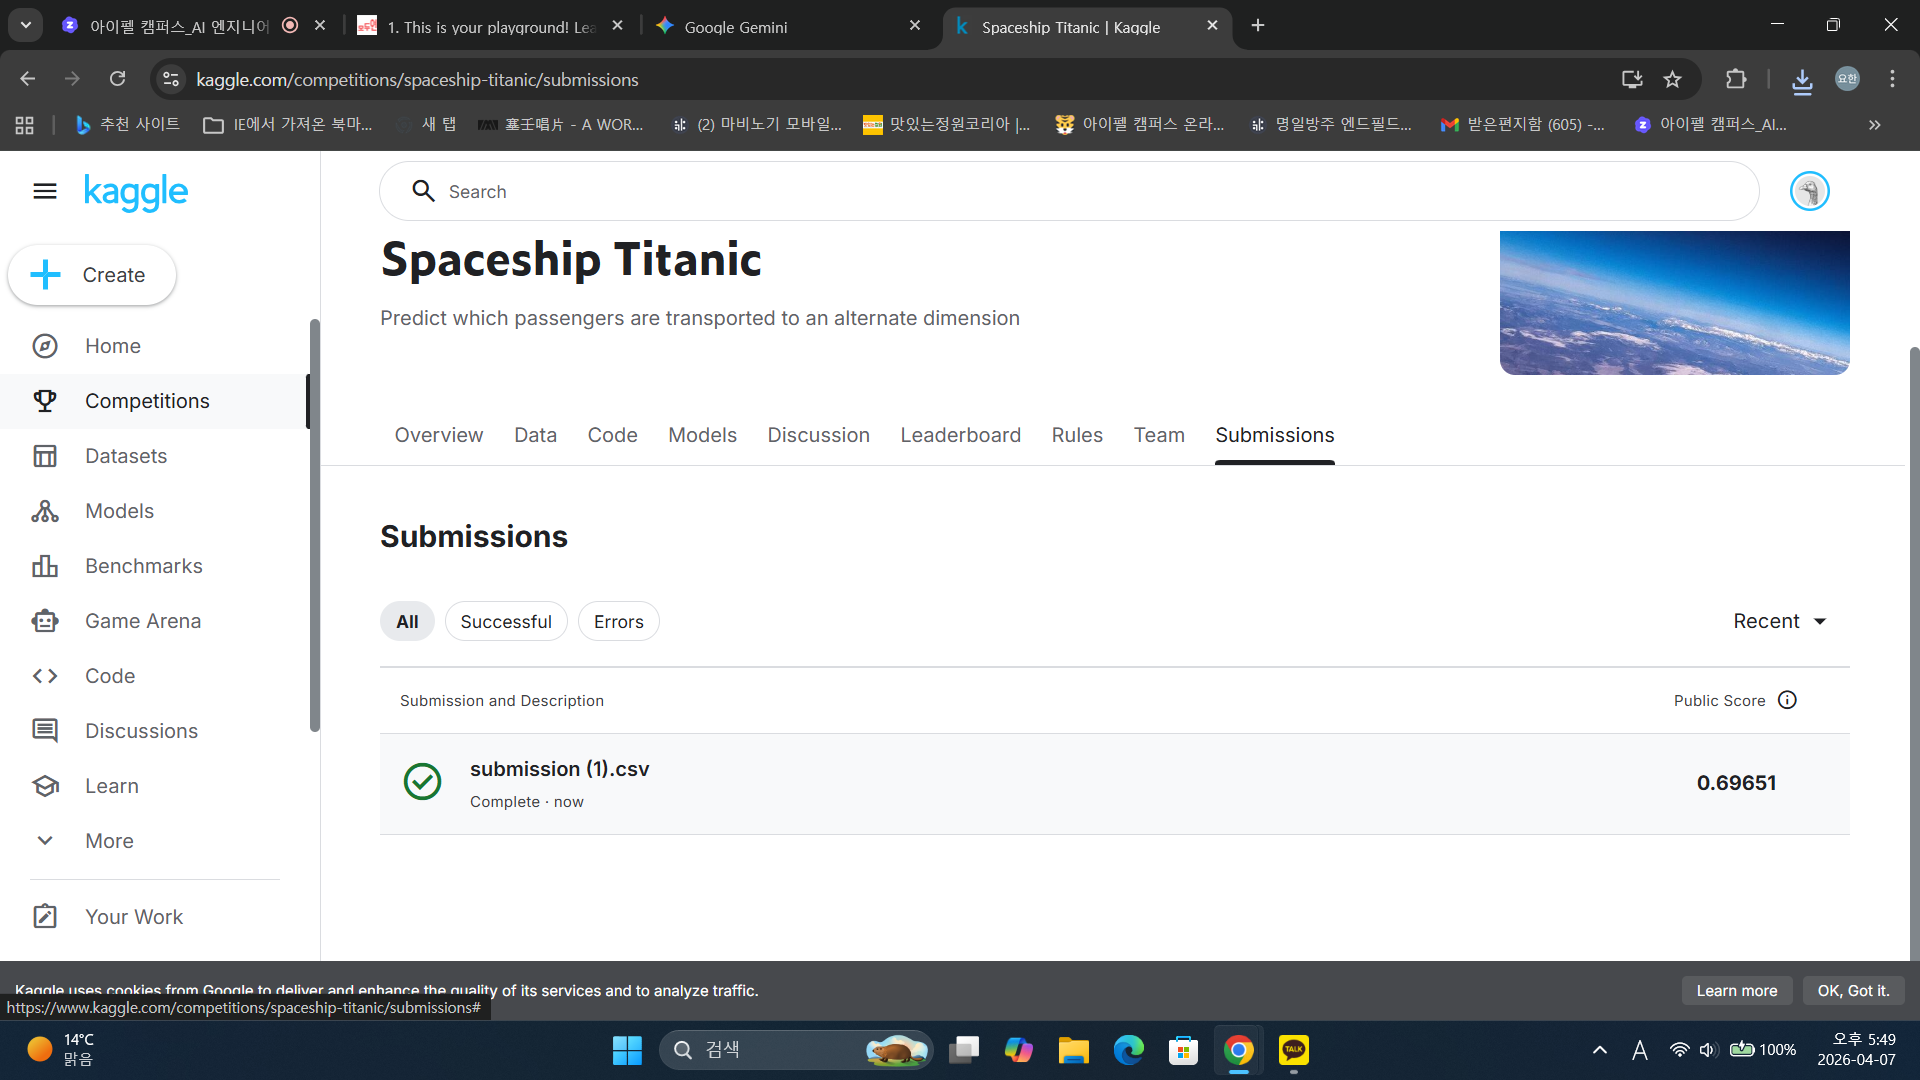

### 목차
1. 데이터 확인
2. EDA
3. 피처 엔지니어링
4. 모델학습과 예측
5. 모델 개선

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
### 시각화 모듈 불러오기

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
from os.path import join

In [3]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [4]:
train_data_path = 'train.csv'
test_data_path = 'test.csv'

In [5]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)
print('train data dim : {}'.format(train.shape))
print('test data dim : {}'.format(test.shape))

train data dim : (8693, 14)
test data dim : (4277, 13)


# 1. 데이터 파악하기
 
 

In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


페신저 넘버, 모행성, 수면캡슐, 그룹, 나이, VIP여부, 지출내열(룸서비스, 푸드코드, 쇼핑몰, 스파, VR덱), 이름, 시공간여부

In [7]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


결측치를 살펴보기.

In [8]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [9]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

<Axes: >

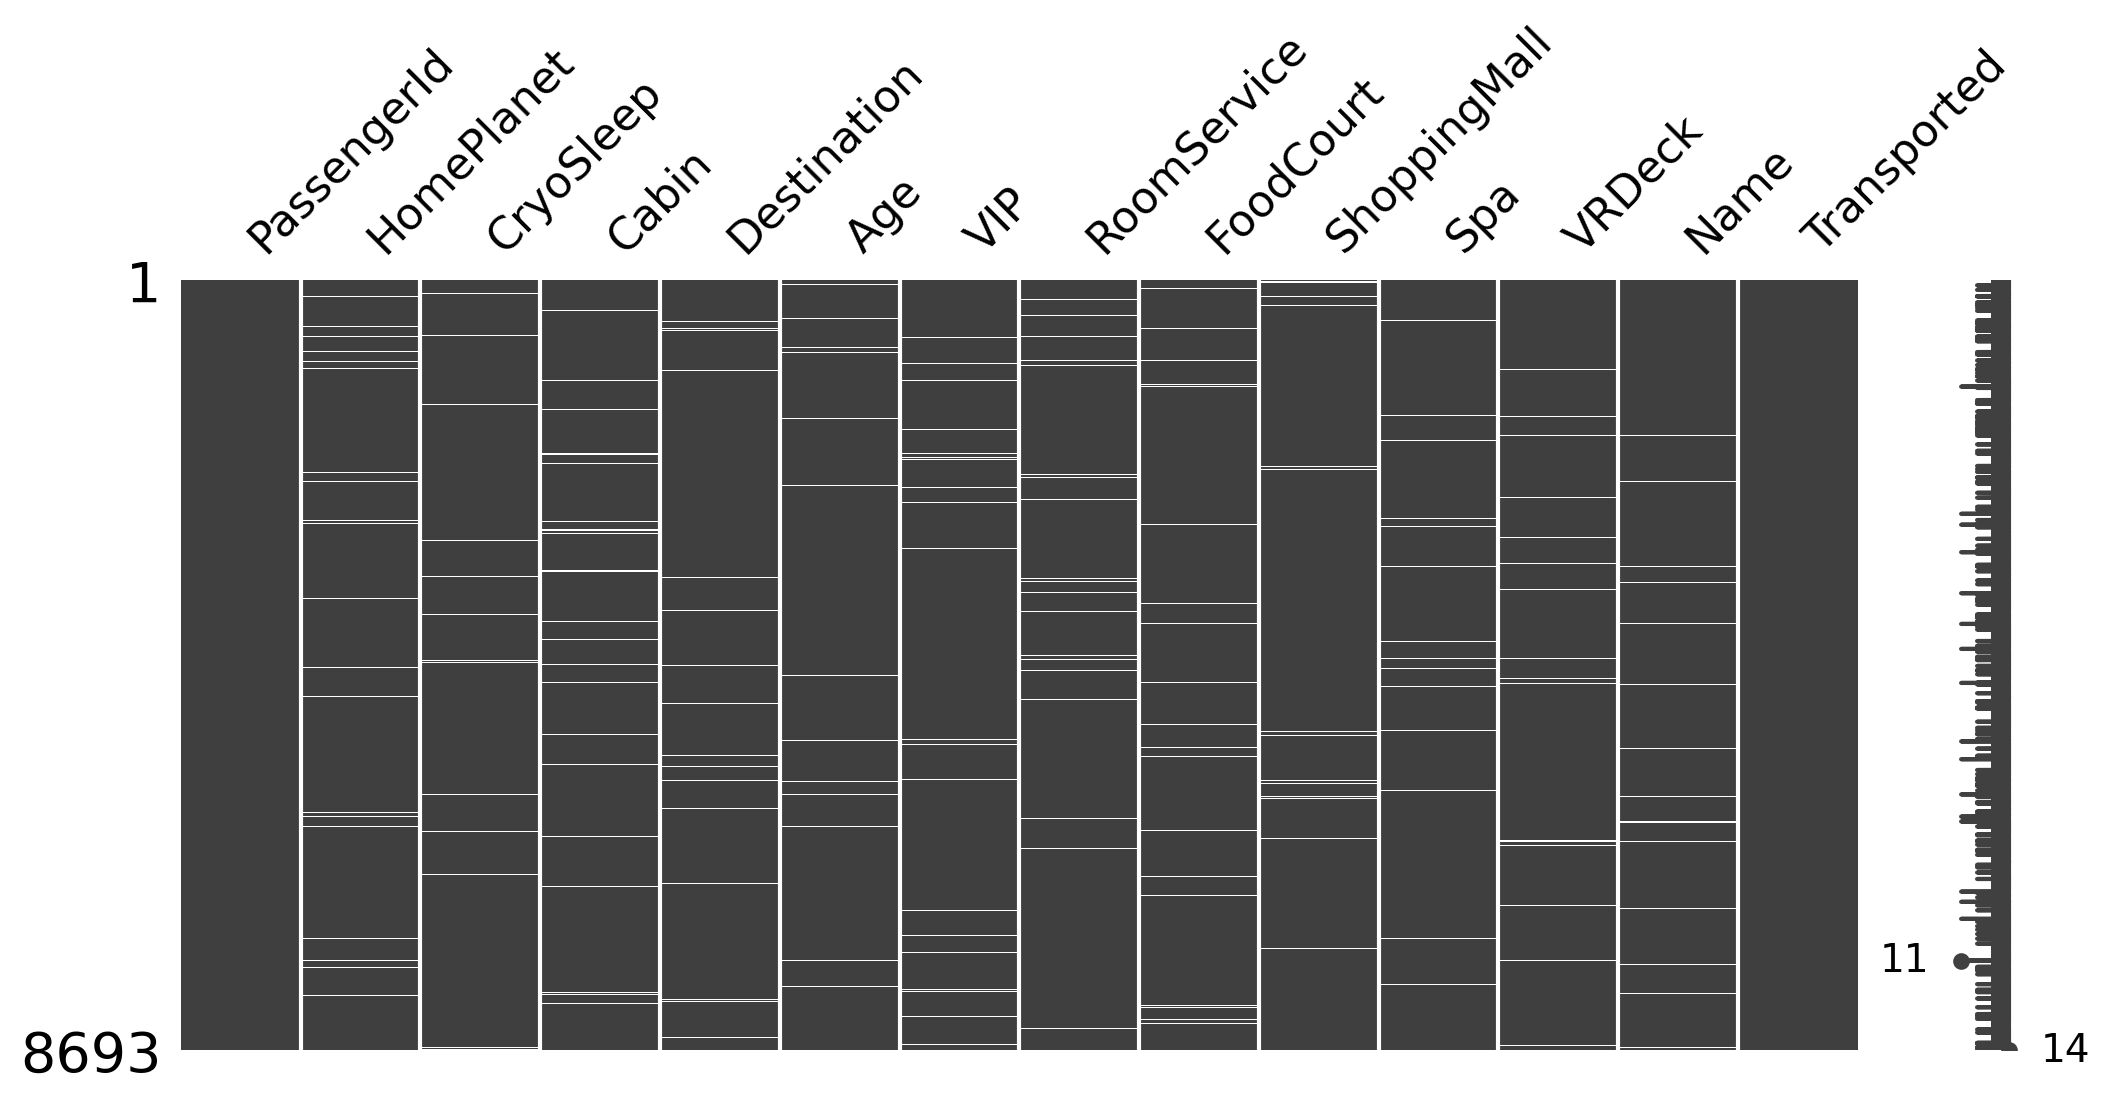

In [10]:
###결측치 시각화
import missingno as msno
msno.matrix(train, figsize=(12, 5))

<Axes: >

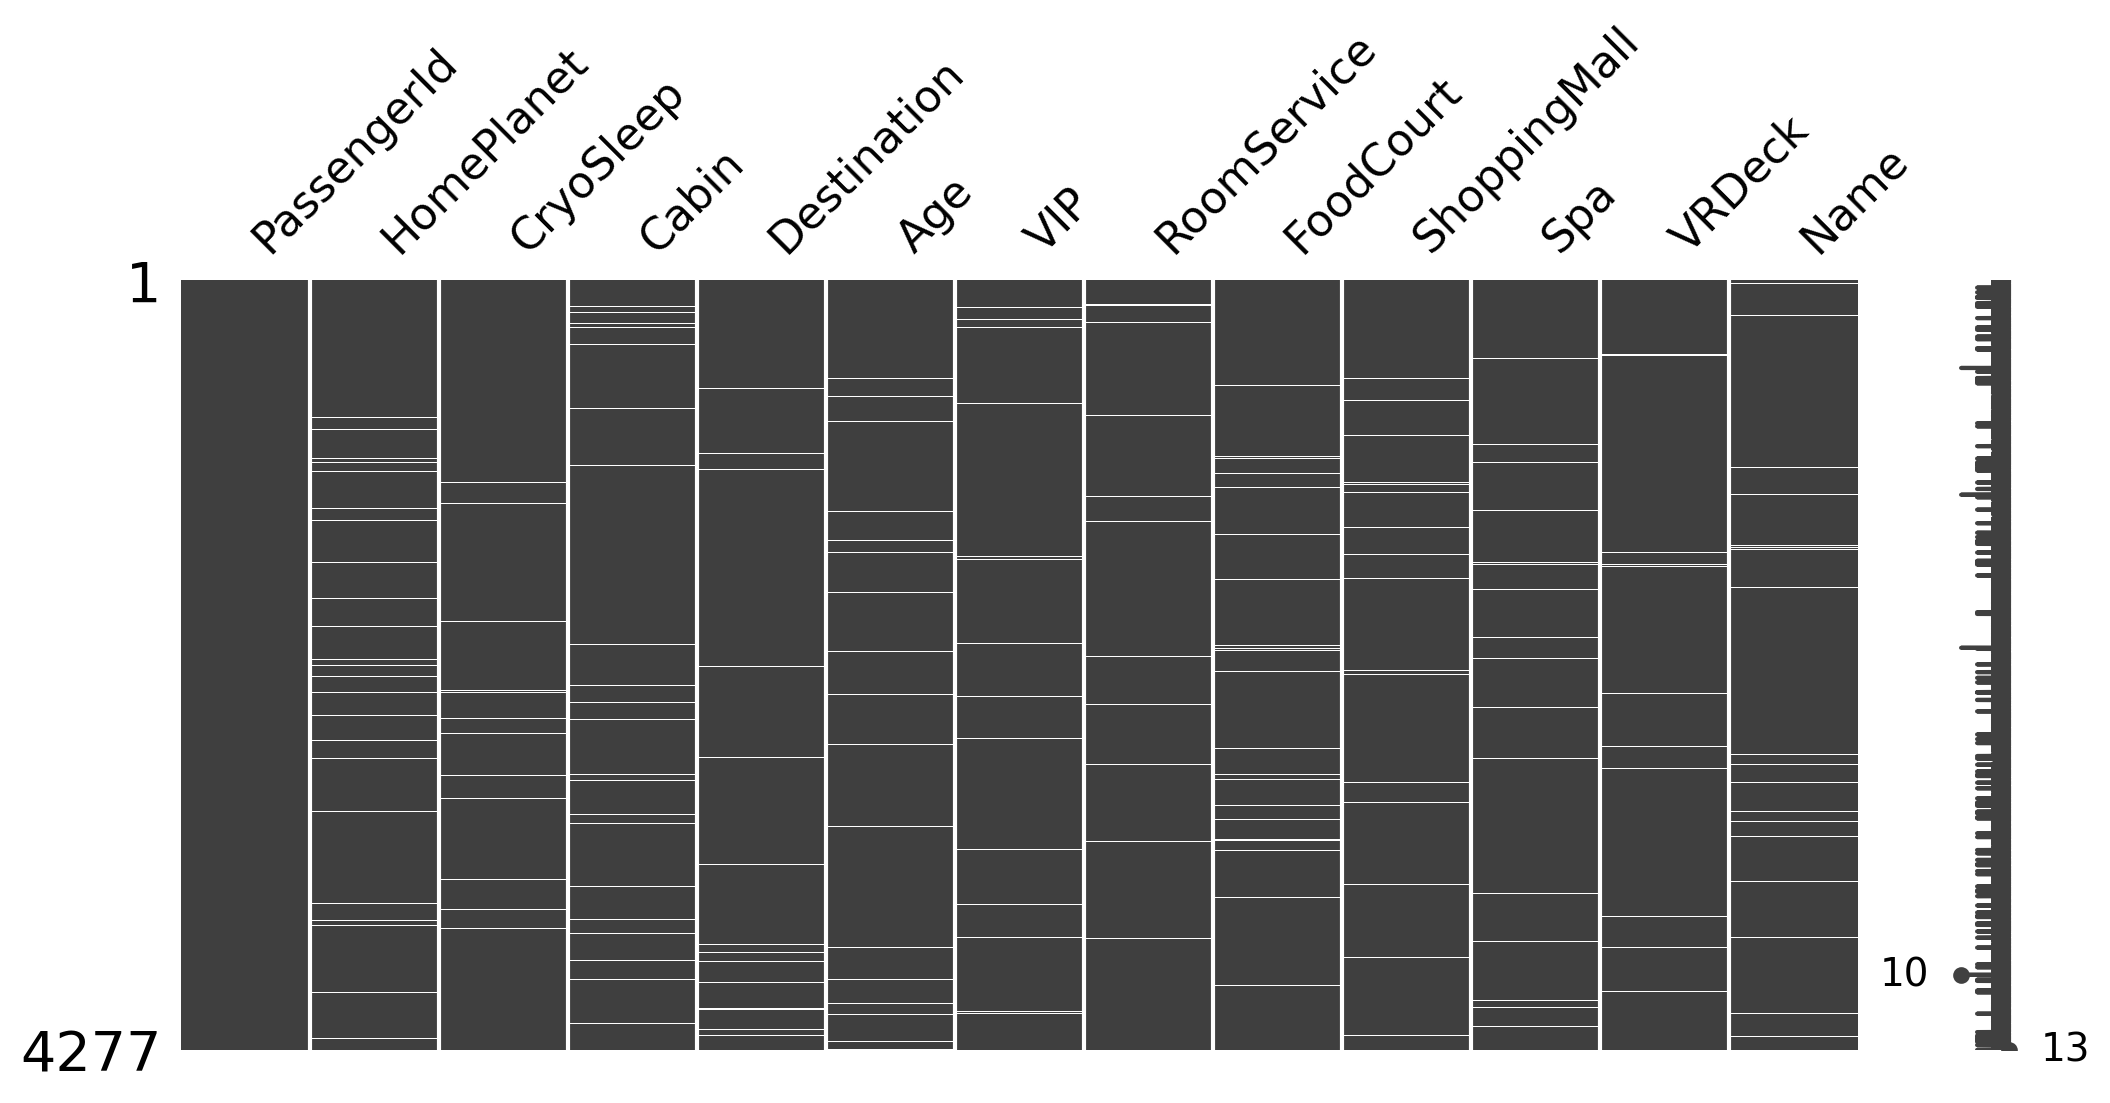

In [11]:
msno.matrix(test, figsize=(12, 5))

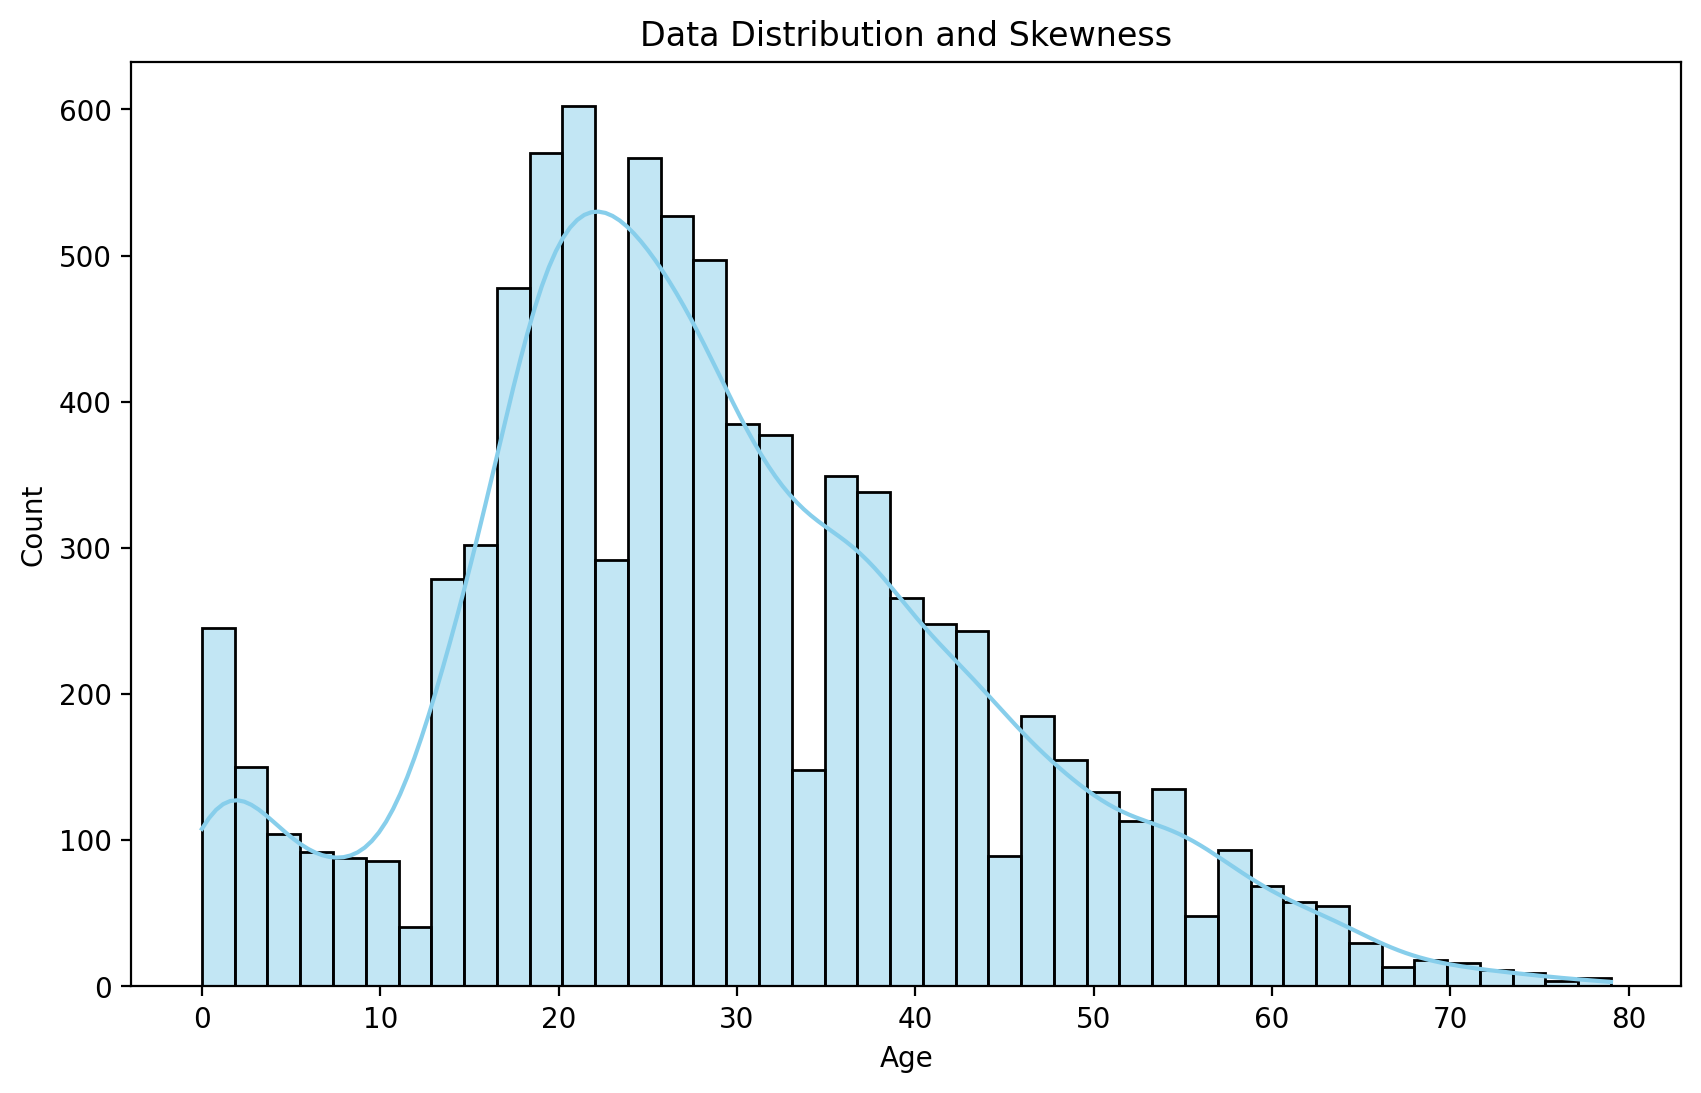

In [12]:
### 편중도 시각화
plt.figure(figsize=(10, 6))

# 히스토그램과 선(KDE)을 함께 그림
sns.histplot(train['Age'], kde=True, color='skyblue')

plt.title('Data Distribution and Skewness')
plt.show()

# 2. EDA
## 2-1. 시공간사고 비율

<Axes: ylabel='count'>

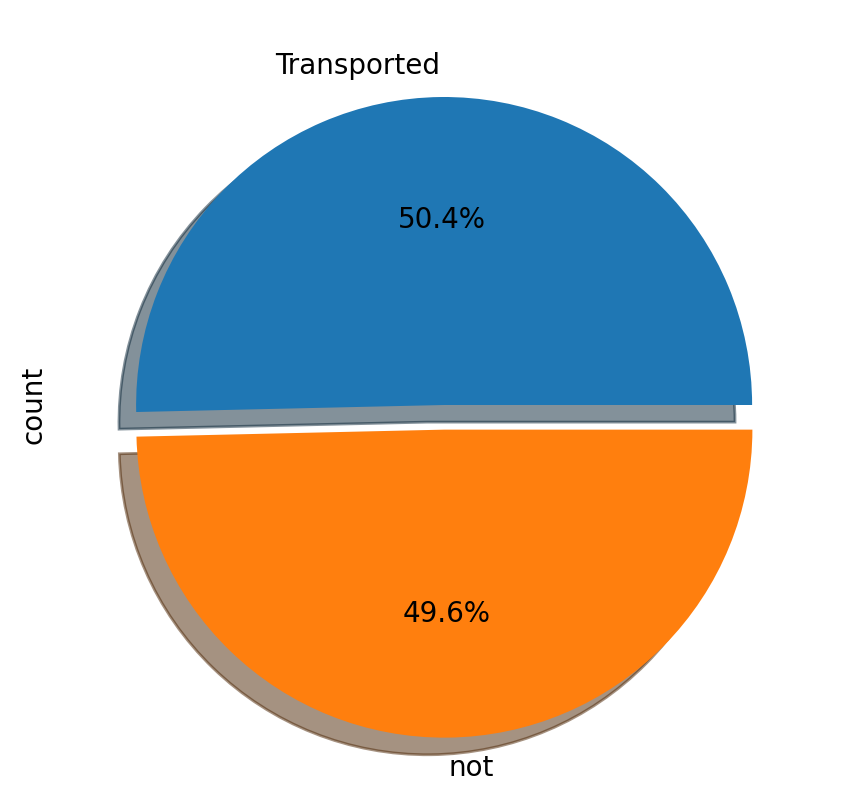

In [13]:
# 양성비율 확인
train["Transported"].value_counts()

plt.figure(figsize=(8, 5))
labels = ['Transported', 'not']
train['Transported'].value_counts().plot.pie(explode=[0, 0.08], 
                                          shadow=True,
                                          autopct='%1.1f%%',
                                          labels=labels)

## 2-2. 모별에 따른 시공간사고 비율

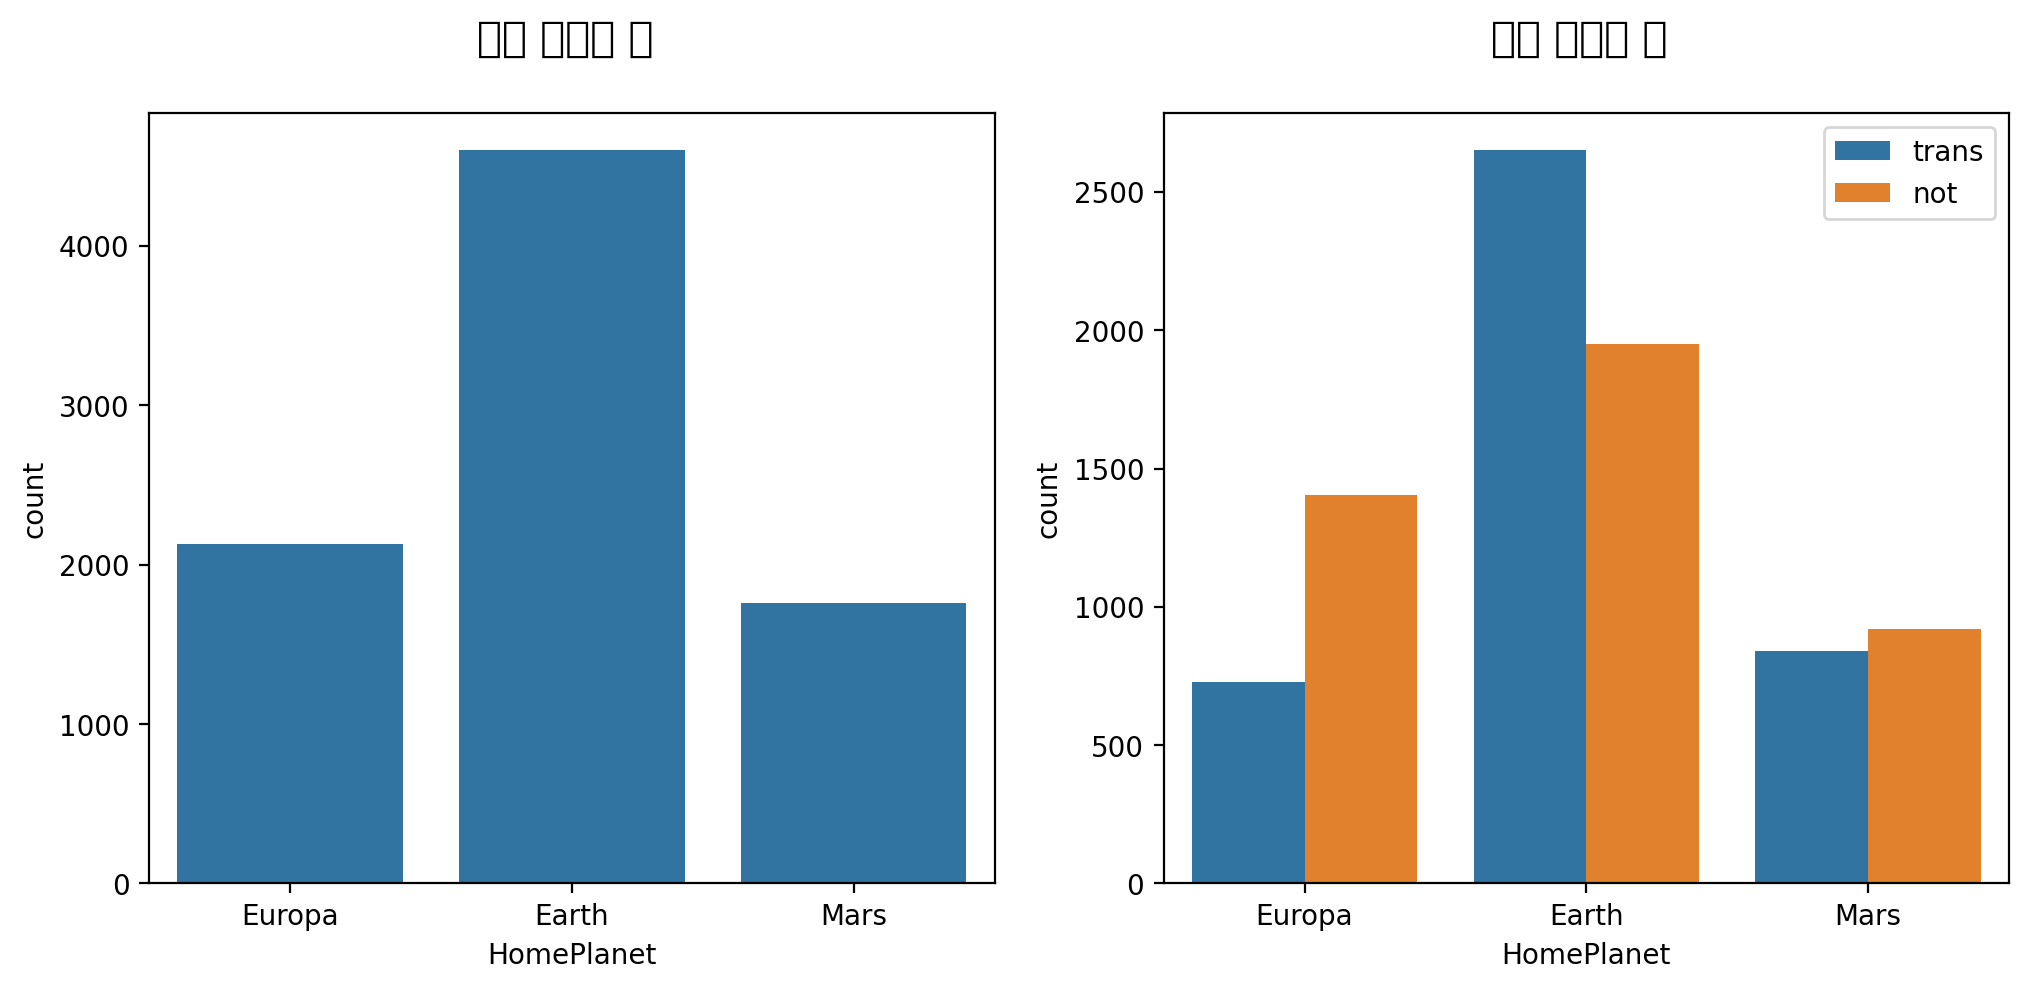

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("모별 탑승자 수 \n", size=15)
sns.countplot(x="HomePlanet", data=train, ax=axes[0])

axes[1].set_title("모별 생존자 수 \n", size=15)
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['trans', 'not'])

지구 출신이 시공간사고에 양의 상관관계가 있어보입니다.  
유로파출신은 오히려 음의 상관관계가 있네요.

## 2-3. 냉동수면 양성비율

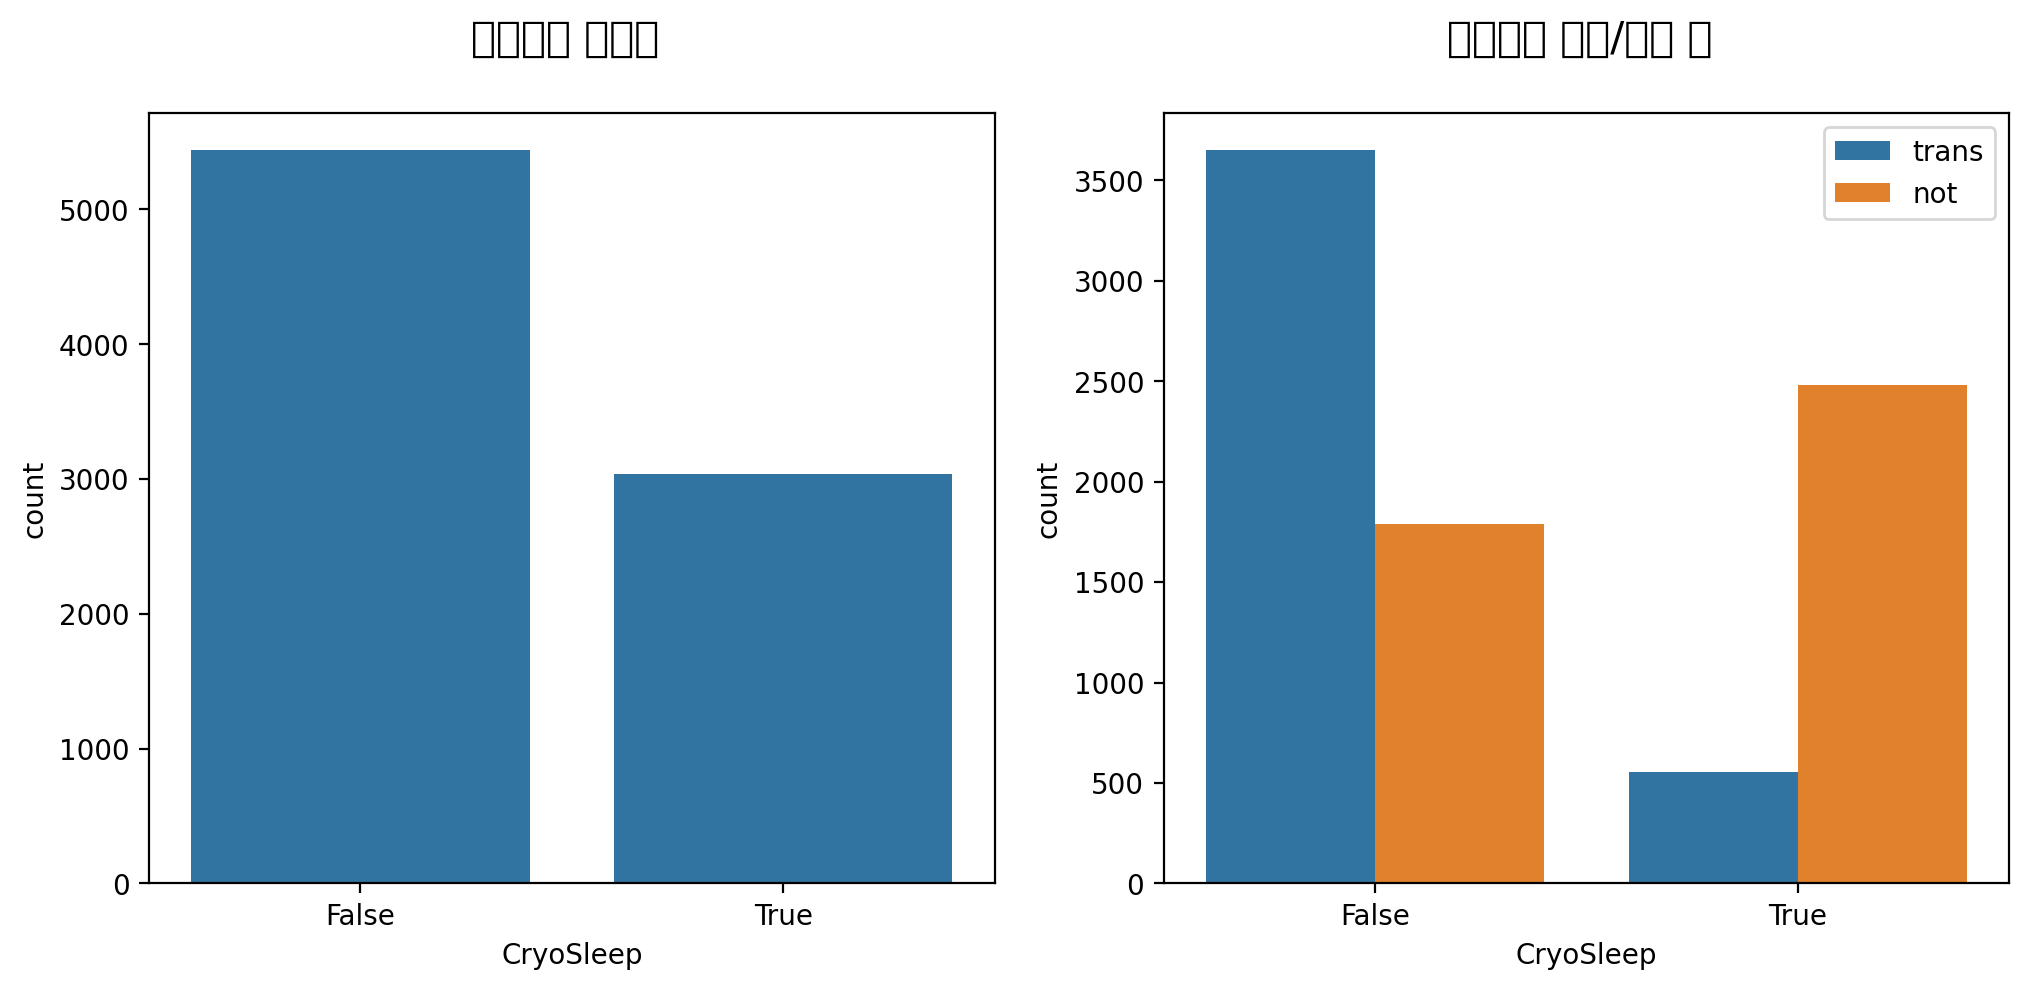

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("클래스별 탑승수 \n", size=15)
sns.countplot(data=train, x='CryoSleep', ax=axes[0])

axes[1].set_title("클래스별 생존/사망 수 \n", size=15)
sns.countplot(x="CryoSleep", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['trans', 'not'])

### 냉동수면시 시공간사고를 당할 확률이 적어보입니다.

## 2-4. 나이에 따른 시공간사고 비율

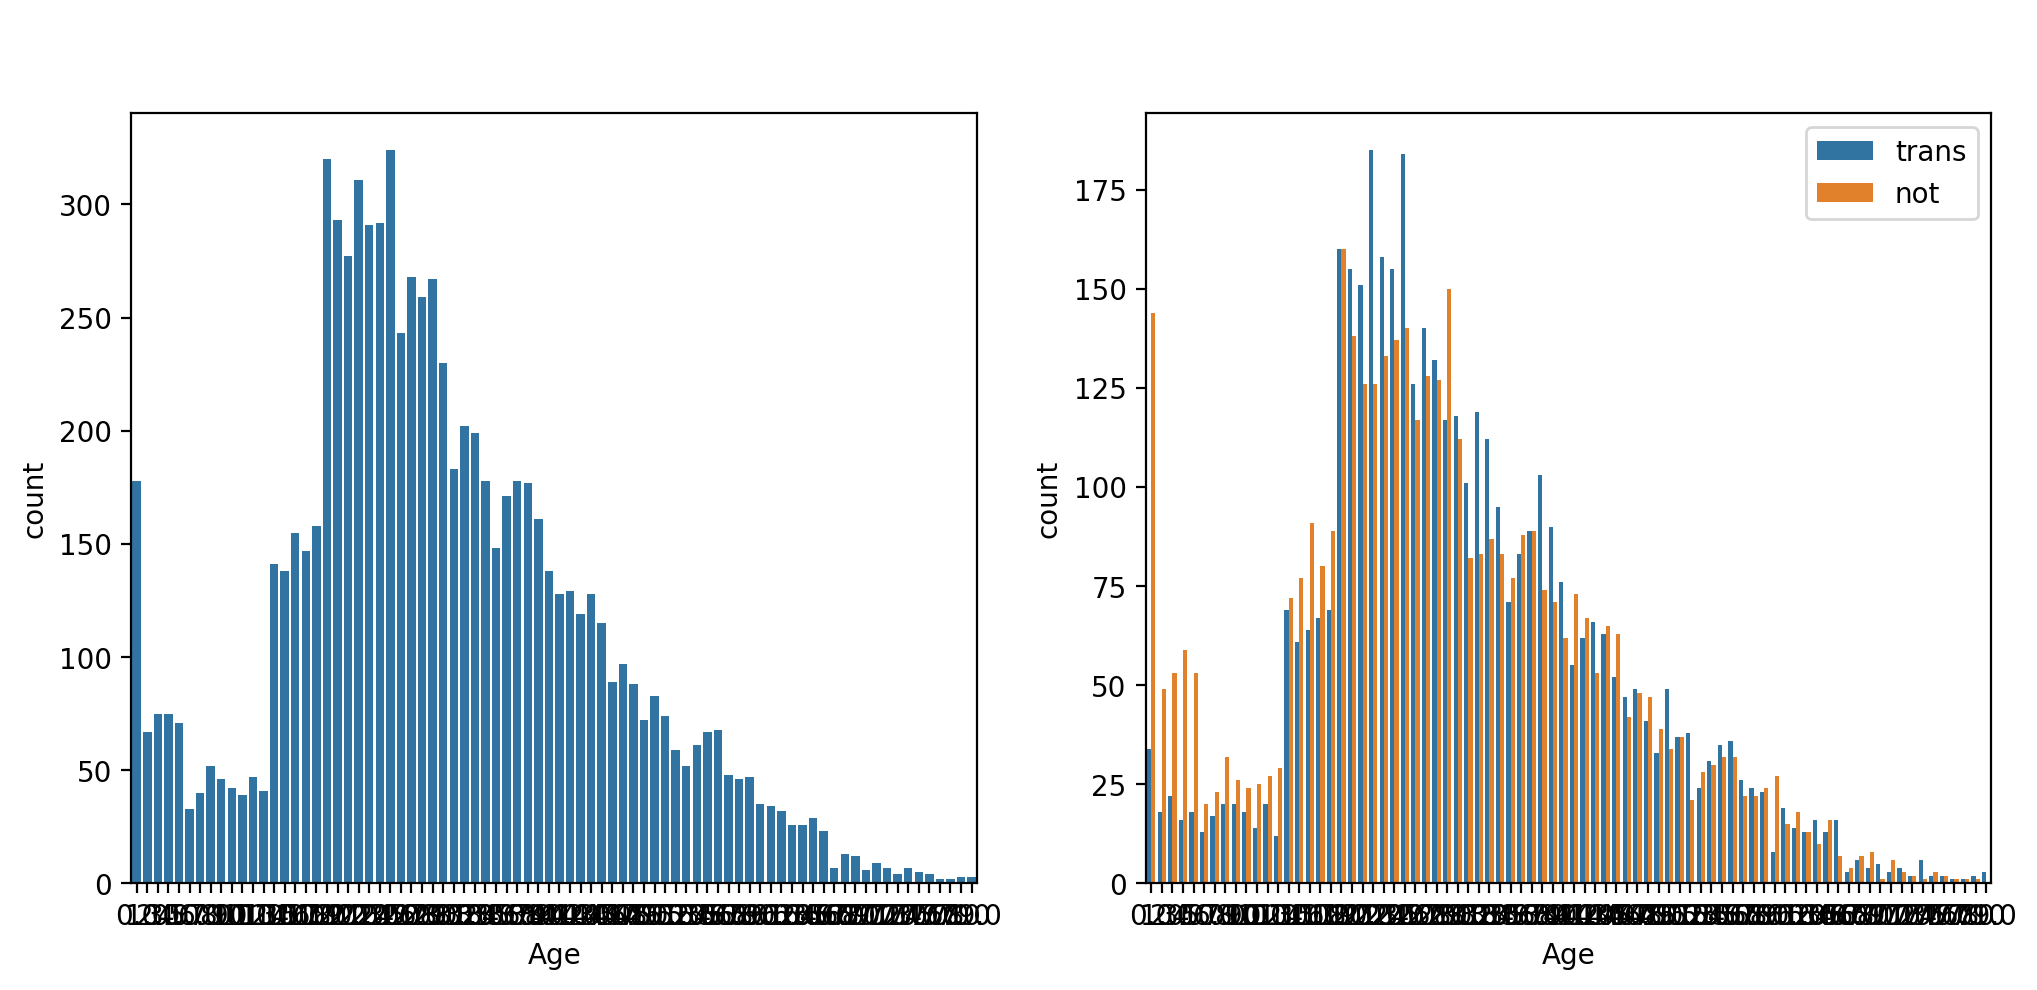

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title(" \n", size=15)
sns.countplot(data=train, x='Age', ax=axes[0])

axes[1].set_title(" \n", size=15)
sns.countplot(x="Age", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['trans', 'not'])

<Axes: xlabel='Age', ylabel='Density'>

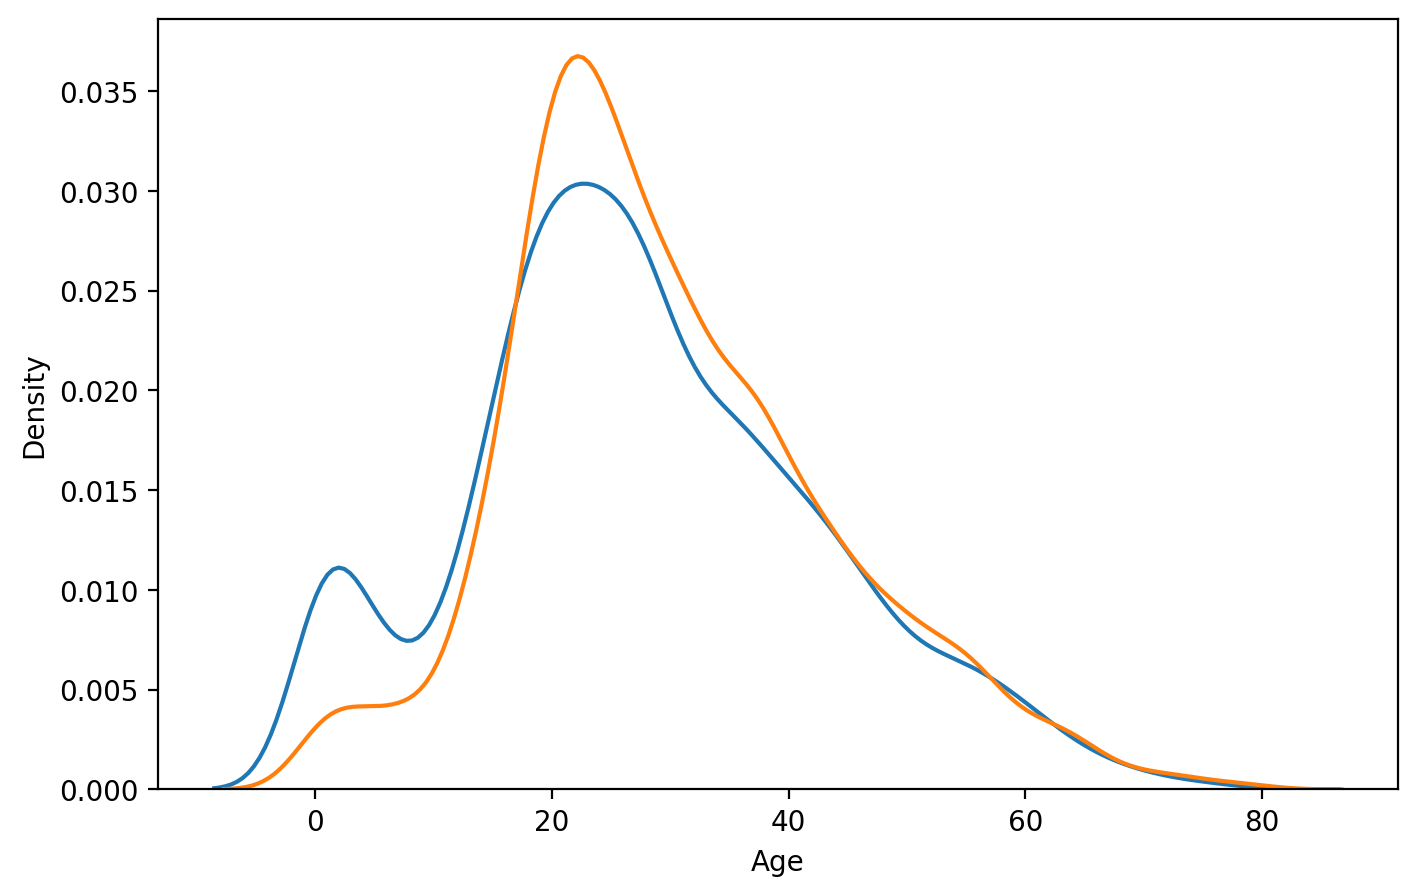

In [17]:
sur = train[train['Transported'] == 1]
dead = train[train['Transported'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(sur['Age'], bins=25, hist=False)
sns.distplot(dead['Age'], bins=25, hist=False)

## 0살에 가까운 나이일수록 사고 비율이 높아집니다.

### 2-5. vip와 시공간사고 비율

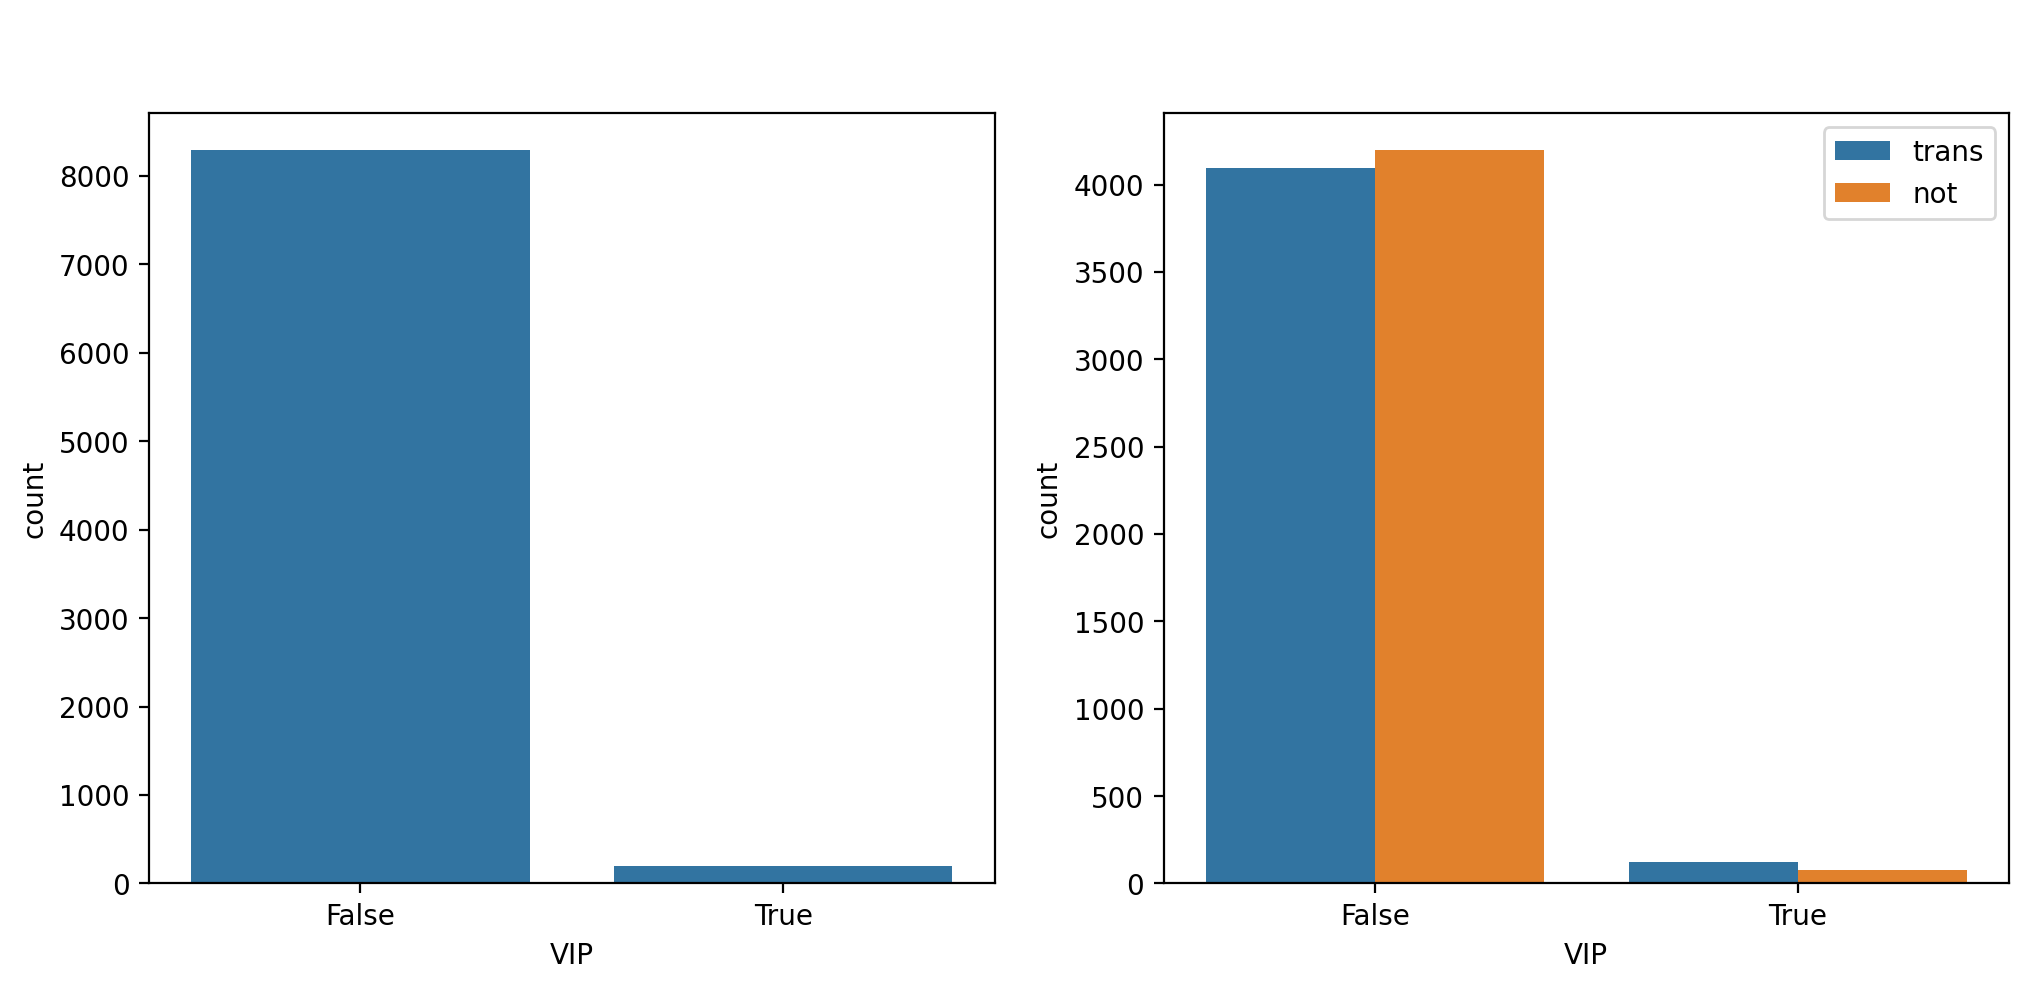

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title(" \n", size=15)
sns.countplot(data=train, x='VIP', ax=axes[0])

axes[1].set_title(" \n", size=15)
sns.countplot(x="VIP", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['trans', 'not'])

2-6 소비지출 내역에 따른 시공간 사고 비율

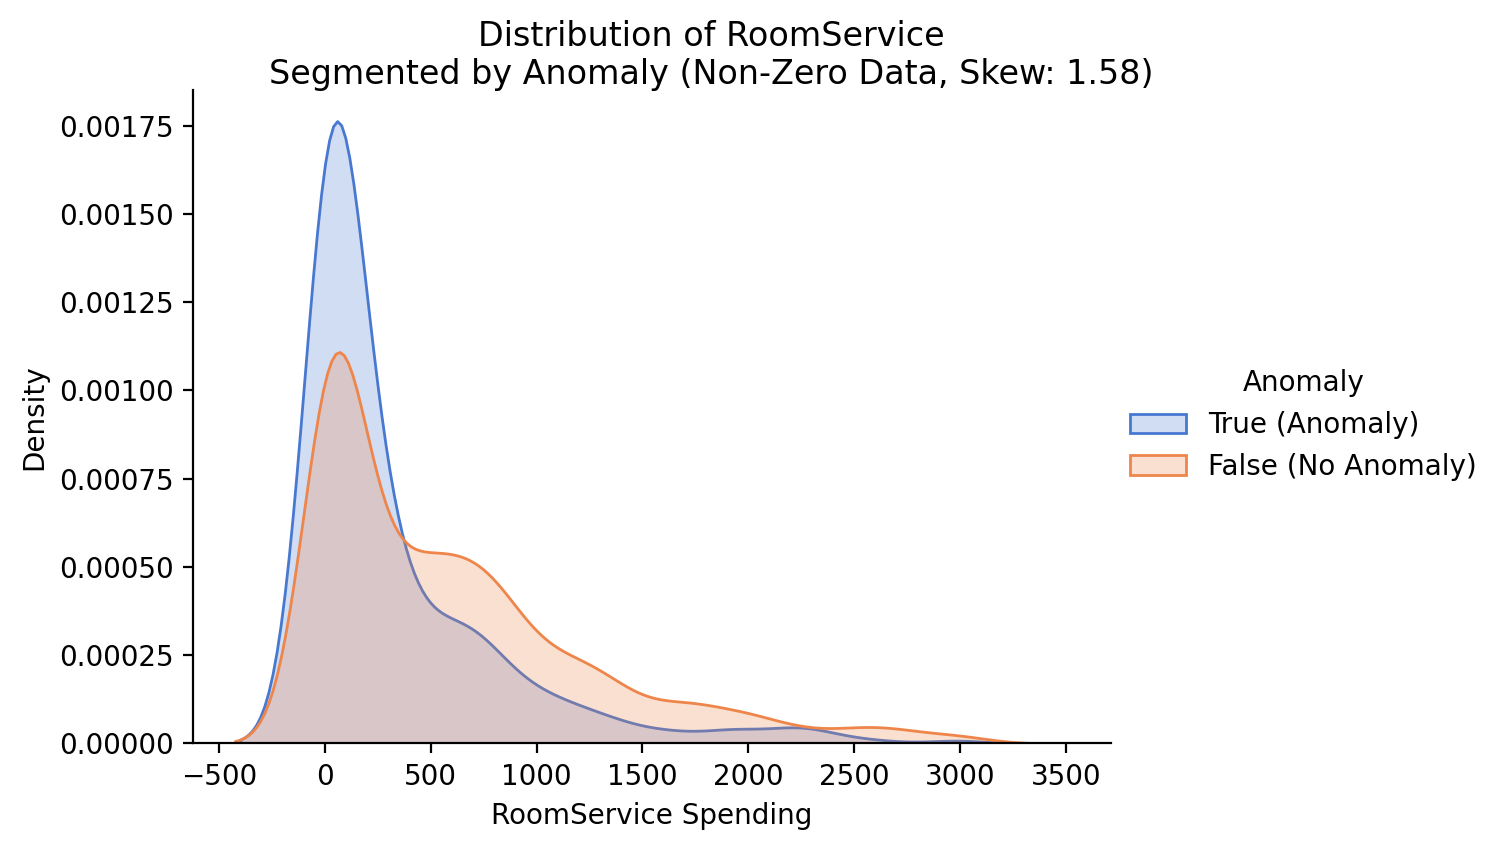

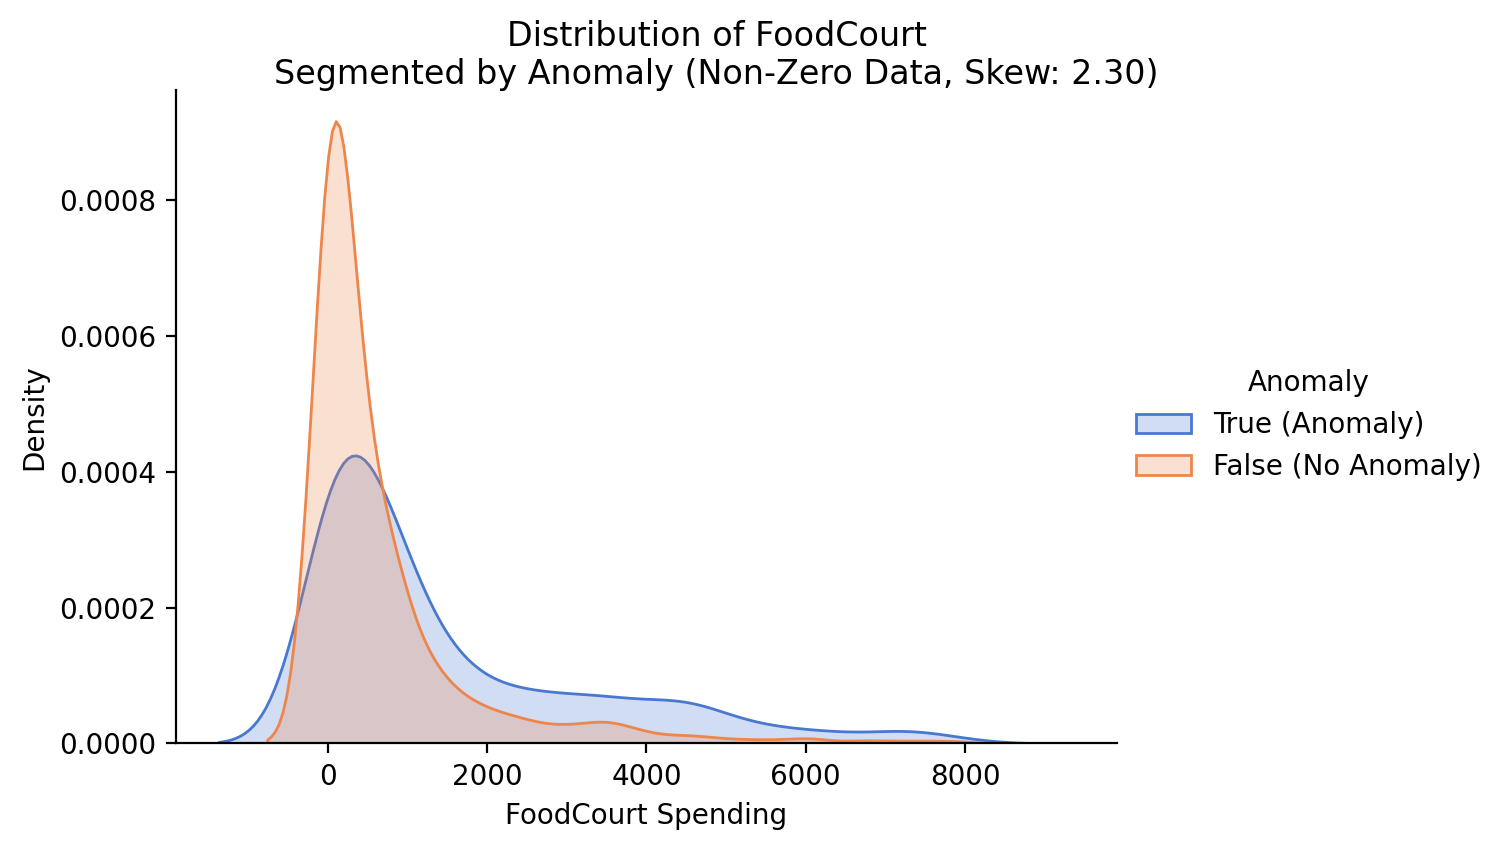

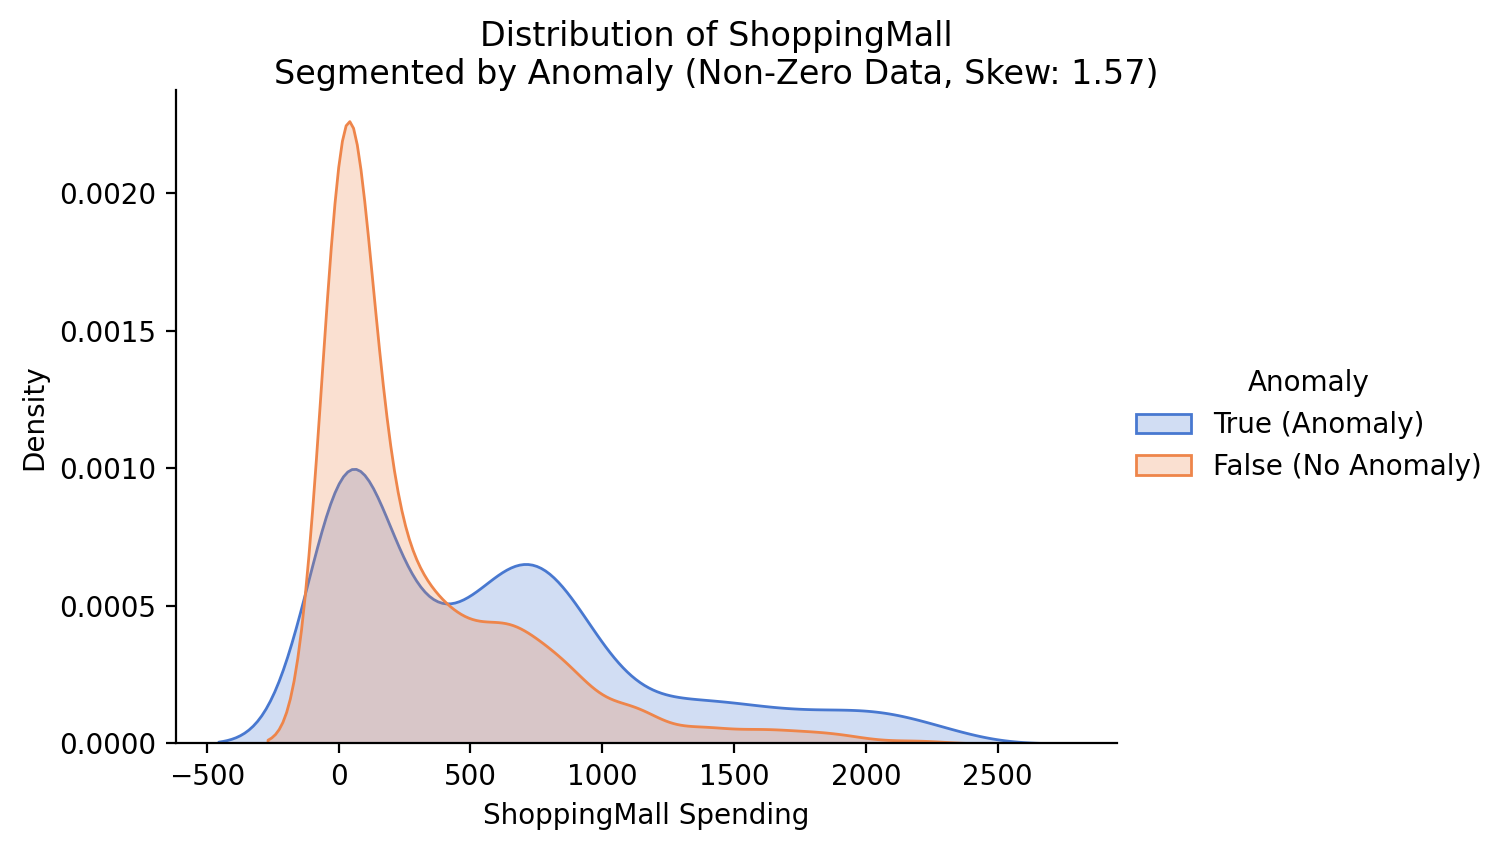

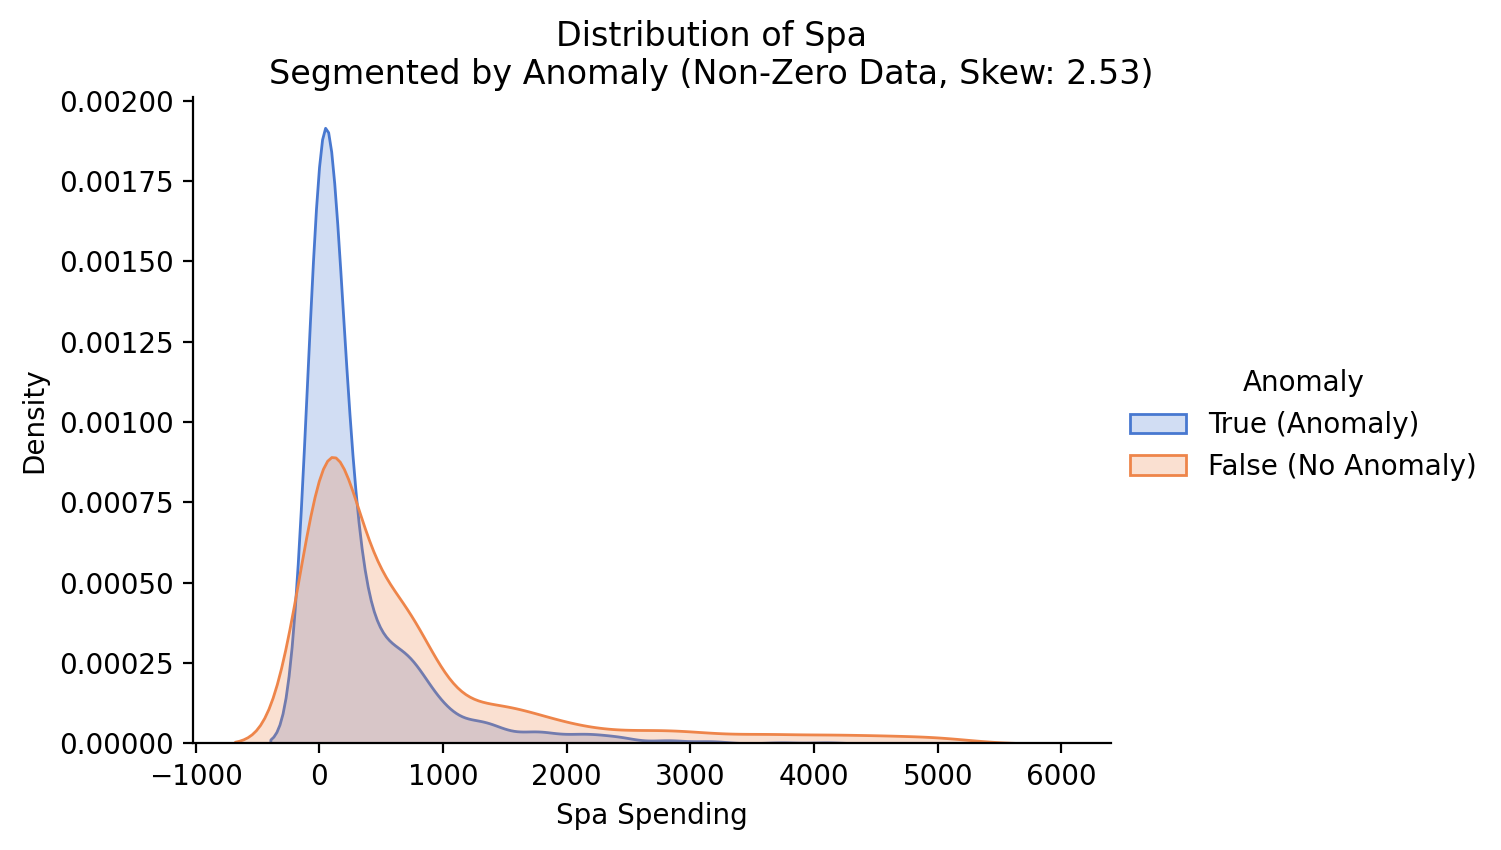

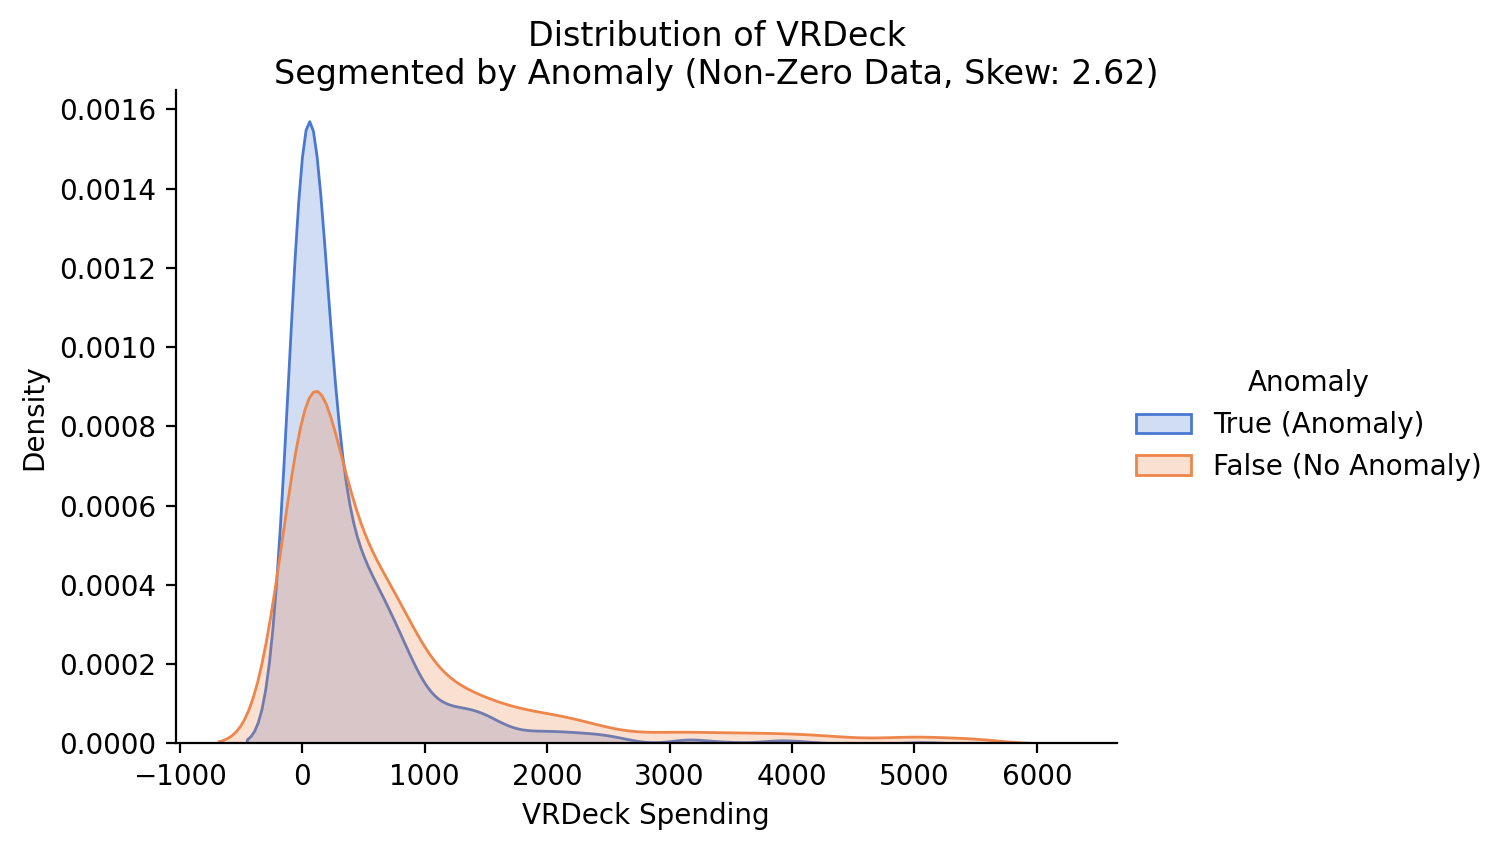

In [19]:
# 분석할 5가지 지출 특성
cols_to_plot = ['RoomService', 'FoodCourt', 'ShoppingMall','Spa', 'VRDeck']

# 시공간사고 컬럼 (bool -> categorical로 임시 변경)
train_viz = train.copy()
train_viz['Anomaly'] = train_viz['Transported'].map({True: 'True (Anomaly)', False: 'False (No Anomaly)'})

# 분포가 극도로 편중되어 있으므로, 0을 제외한 데이터만 보거나 상위 이상치를 제한하여 시각화하는 것이 좋습니다.
for col in cols_to_plot:
    # 0보다 크고 상위 1% 미만인 데이터만 필터링하여 그래프 그리기 (분포 왜곡 완화)
    upper_limit = train_viz[col].quantile(0.99)
    filtered_data = train_viz[(train_viz[col] > 0) & (train_viz[col] < upper_limit)]
    
    # 그래프 생성
    g = sns.FacetGrid(filtered_data, hue='Anomaly', height=4, aspect=1.5, palette='muted')
    g.map(sns.kdeplot, col, fill=True)
    
    # 왜도(Skew) 값 계산
    skew_val = filtered_data[col].skew()
    
    g.set_axis_labels(f'{col} Spending', 'Density')
    g.fig.suptitle(f'Distribution of {col}\nSegmented by Anomaly (Non-Zero Data, Skew: {skew_val:.2f})', y=1.05)
    g.add_legend()
    plt.show()

룸서비스, 스파, VR덱의 소비가 큰 경우 시공간 사고와 상관관계가 있어 보인다.  
반면 쇼핑몰과 푸드코트를 이용한 사람들은 덜 영향받은거 같다.

### 가설 1: 소비지출 총액이 높을수록 사고에 휘말렸을수도 있다고 가정.  
이를 검증하기 위해 결측치를 0으로 채우고 총 소비액을 구해서 확인해본다.

In [20]:
# 1. 지출 관련 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 결측치를 0으로 임시 대체하고 총 지출(TotalSpending) 계산
train['TotalSpending'] = train[exp_cols].fillna(0).sum(axis=1)

# 3. 지출 규모에 따른 그룹화 (분석을 위해 구간 분할)
# 지출이 0인 그룹과 그렇지 않은 그룹의 차이가 크므로 0을 별도로 분리합니다.
def get_spend_group(x):
    if x == 0: return 'Zero'
    elif x < 1000: return 'Low'
    elif x < 3000: return 'Medium'
    else: return 'High'

train['SpendingGroup'] = train['TotalSpending'].apply(get_spend_group)

# 4. 그룹별 사고 발생(Transported) 비율 계산
spend_analysis = train.groupby('SpendingGroup')['Transported'].mean().sort_values()
print("--- 소비 그룹별 사고 발생 비율 ---")
print(spend_analysis)

--- 소비 그룹별 사고 발생 비율 ---
SpendingGroup
Medium    0.281887
Low       0.293158
High      0.335125
Zero      0.786477
Name: Transported, dtype: float64


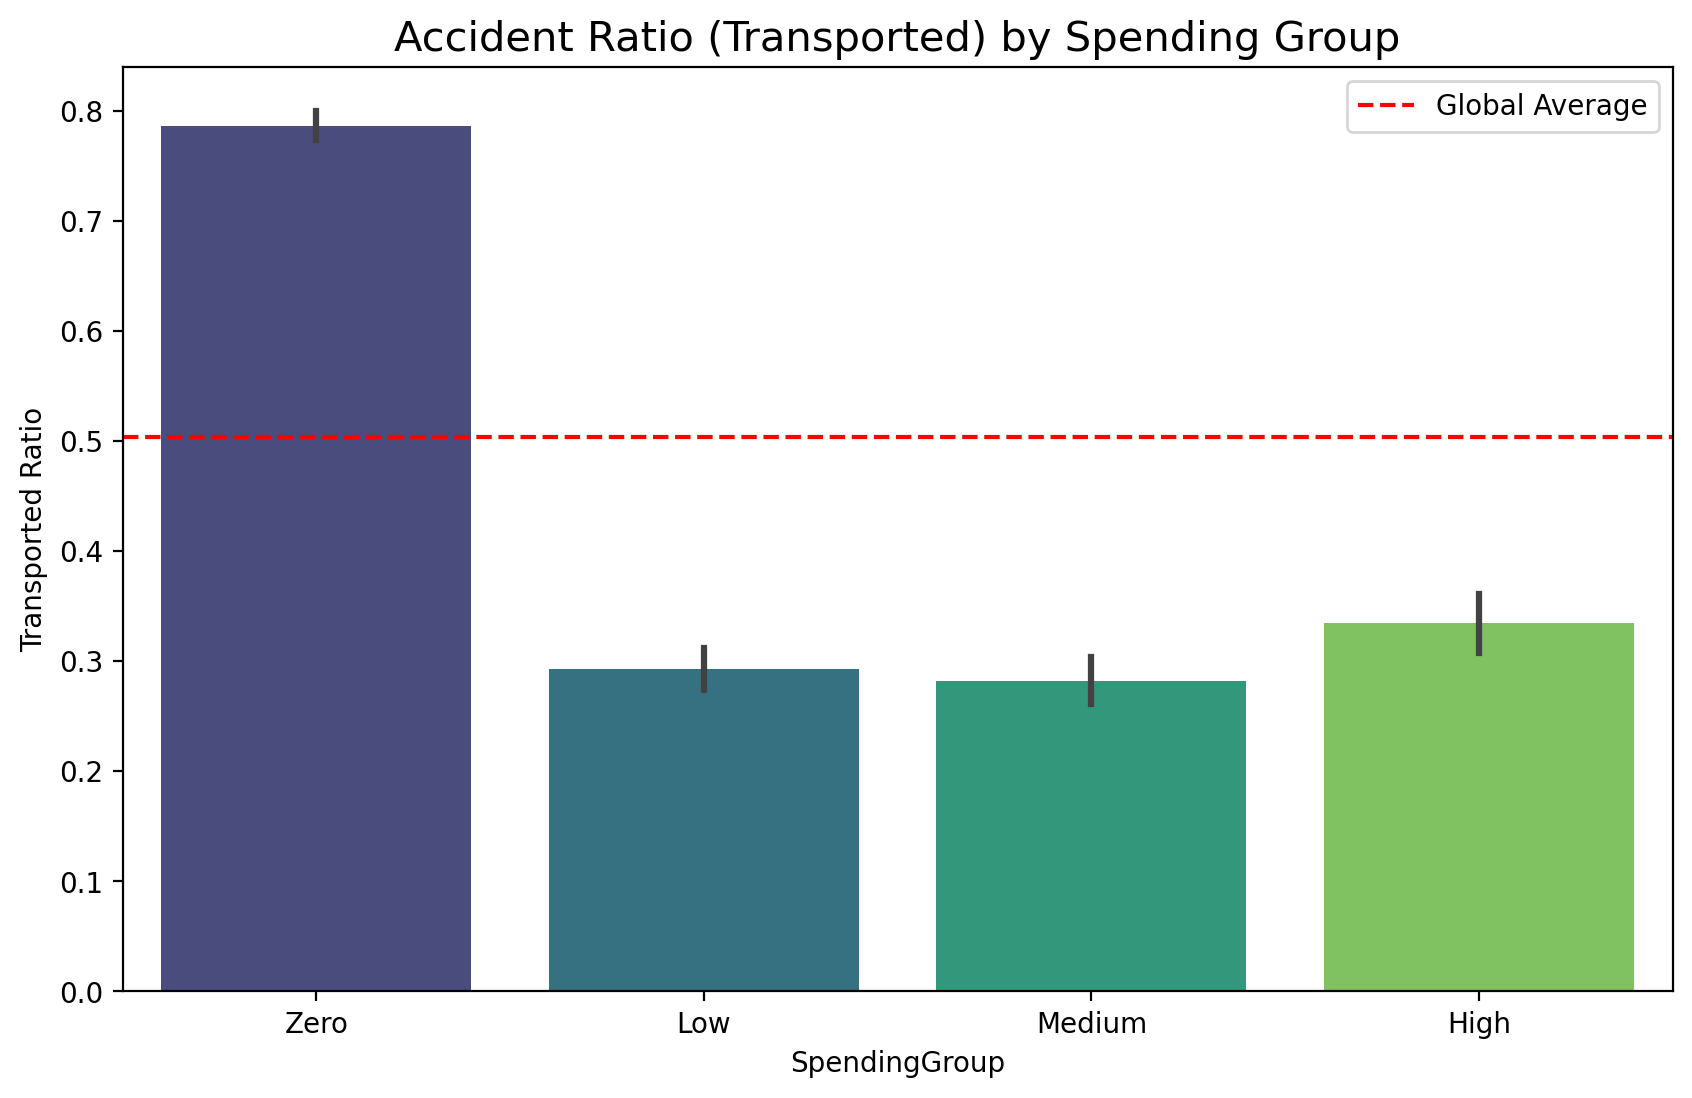

In [21]:
plt.figure(figsize=(10, 6))
# 순서를 직관적으로 정렬 (Zero -> Low -> Medium -> High)
order = ['Zero', 'Low', 'Medium', 'High']

sns.barplot(data=train, x='SpendingGroup', y='Transported', order=order, palette='viridis')

# 전체 평균선 표시 (전체 사고율 대비 높은지 낮은지 확인)
plt.axhline(train['Transported'].mean(), color='red', linestyle='--', label='Global Average')

plt.title('Accident Ratio (Transported) by Spending Group', size=15)
plt.ylabel('Transported Ratio')
plt.legend()
plt.show()

### 제로그룹이 높은 이유에 대해 생각해보자.
- 동면중이면 소비가 0일 것이다.

In [22]:
# 동면하지 않는 승객들만 따로 추출해서 비교해 보세요!
non_cryo_train = train[train['CryoSleep'] == False]

In [23]:
# 1. 지출 관련 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 결측치를 0으로 임시 대체하고 총 지출(TotalSpending) 계산
train['TotalSpending'] = non_cryo_train[exp_cols].fillna(0).sum(axis=1)

# 3. 지출 규모에 따른 그룹화 (분석을 위해 구간 분할)
# 지출이 0인 그룹과 그렇지 않은 그룹의 차이가 크므로 0을 별도로 분리합니다.
def get_spend_group(x):
    if x == 0: return 'Zero'
    elif x < 1000: return 'Low'
    elif x < 3000: return 'Medium'
    else: return 'High'

train['SpendingGroup'] = train['TotalSpending'].apply(get_spend_group)

# 4. 그룹별 사고 발생(Transported) 비율 계산
spend_analysis = train.groupby('SpendingGroup')['Transported'].mean().sort_values()
print("--- 소비 그룹별 사고 발생 비율 ---")
print(spend_analysis)

--- 소비 그룹별 사고 발생 비율 ---
SpendingGroup
Medium    0.284173
Low       0.292052
Zero      0.615830
High      0.679945
Name: Transported, dtype: float64


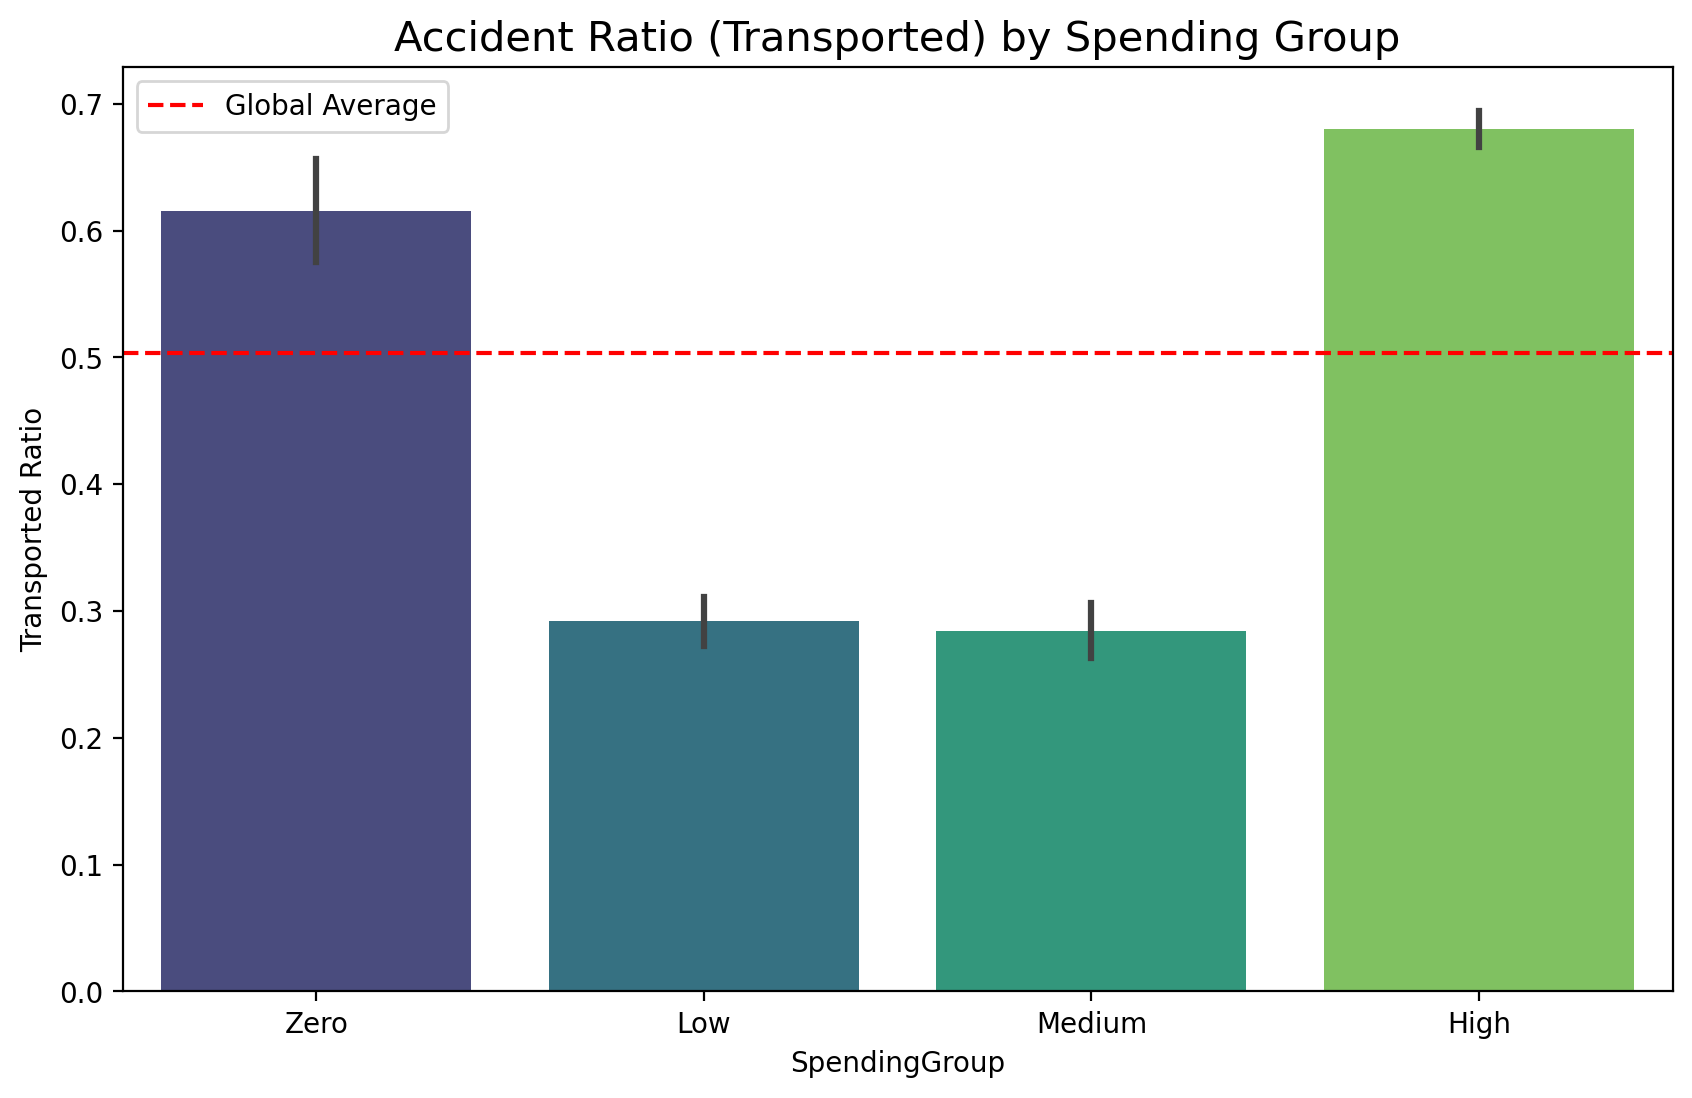

In [24]:
plt.figure(figsize=(10, 6))
# 순서를 직관적으로 정렬 (Zero -> Low -> Medium -> High)
order = ['Zero', 'Low', 'Medium', 'High']

sns.barplot(data=train, x='SpendingGroup', y='Transported', order=order, palette='viridis')

# 전체 평균선 표시 (전체 사고율 대비 높은지 낮은지 확인)
plt.axhline(train['Transported'].mean(), color='red', linestyle='--', label='Global Average')

plt.title('Accident Ratio (Transported) by Spending Group', size=15)
plt.ylabel('Transported Ratio')
plt.legend()
plt.show()

- 소비지출이 높은 계층과 0인 그룹이 사고율이 높아 보인다.  
- 소비가 높은 그룹이 가지는 어떤 특성과 소비가 0인 그룹이 가지는 어떤 특성이 시공간사고와 밀접한 영향이 있다.

### 가설2 : 소비지출에 영향을 주는 특성인 나이와 출신행성, 객실 위치과의 관계성 알아보기.
- 앞서 살펴본 나이별 사고 비중을 보면 어린아이 그룹이 시공간사고에 영햘 받았을 확률이 높다고 생각되어진다.
- 실제 사고비율을 보고 높다면 어린이 그룹이 제외한체 소비패턴과 사고관계를 고려해보자.
- 또한 출신 행성에 따라 승객들의 소비지출에 영향을 주는지 알아보기 위해 행성도 고려대상에 넣어보자.

In [25]:
# 1. 나이 구간 나누기
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Elderly'])

# 2. 나이대별 평균 소비액 확인
age_spend = train.groupby('AgeGroup', observed=True)['TotalSpending'].mean()
print(age_spend)

AgeGroup
Child         0.000000
Teen       1636.859964
Adult      2522.645892
Elderly    2809.986111
Name: TotalSpending, dtype: float64


In [26]:
# 지출이 0인 사람들 중 어린이의 비율
zero_spend_kids = train[train['TotalSpending'] == 0]['Age'].apply(lambda x: x < 13).mean()
print(f"지출 0원 그룹 중 어린이 비율: {zero_spend_kids:.2%}")

# 어린이(Age < 13)의 사고율 vs 전체 평균 사고율
kid_transported = train[train['Age'] < 13]['Transported'].mean()
print(f"어린이 사고율: {kid_transported:.2%}")

지출 0원 그룹 중 어린이 비율: 78.38%
어린이 사고율: 69.98%


제로그룹이 높게 나오는건 어린이 사고비율이 높아서 이다.  
성인과 청소년 그룹만으로 사고관계를 측정하도록 한다.  
출신행성 특성을 추가해서 사고율을 계산한다.

In [27]:
# 1. 13세 이상의 성인 및 청소년만 추출
adults_df = train[train['Age'] >= 13].copy()

# 2. 소비 그룹별 사고율 계산 (어린이 제외 버전)
adult_spend_analysis = adults_df.groupby(['HomePlanet', 'SpendingGroup'], observed=True)['Transported'].mean().unstack()

print("--- [어린이 제외] 행성 및 소비 그룹별 사고율 ---")
print(adult_spend_analysis)

--- [어린이 제외] 행성 및 소비 그룹별 사고율 ---
SpendingGroup      High       Low    Medium      Zero
HomePlanet                                           
Earth          0.616006  0.297175  0.311522  0.333333
Europa         0.678808  0.428571  0.415730  0.568182
Mars           0.761972  0.214286  0.225352  0.131579


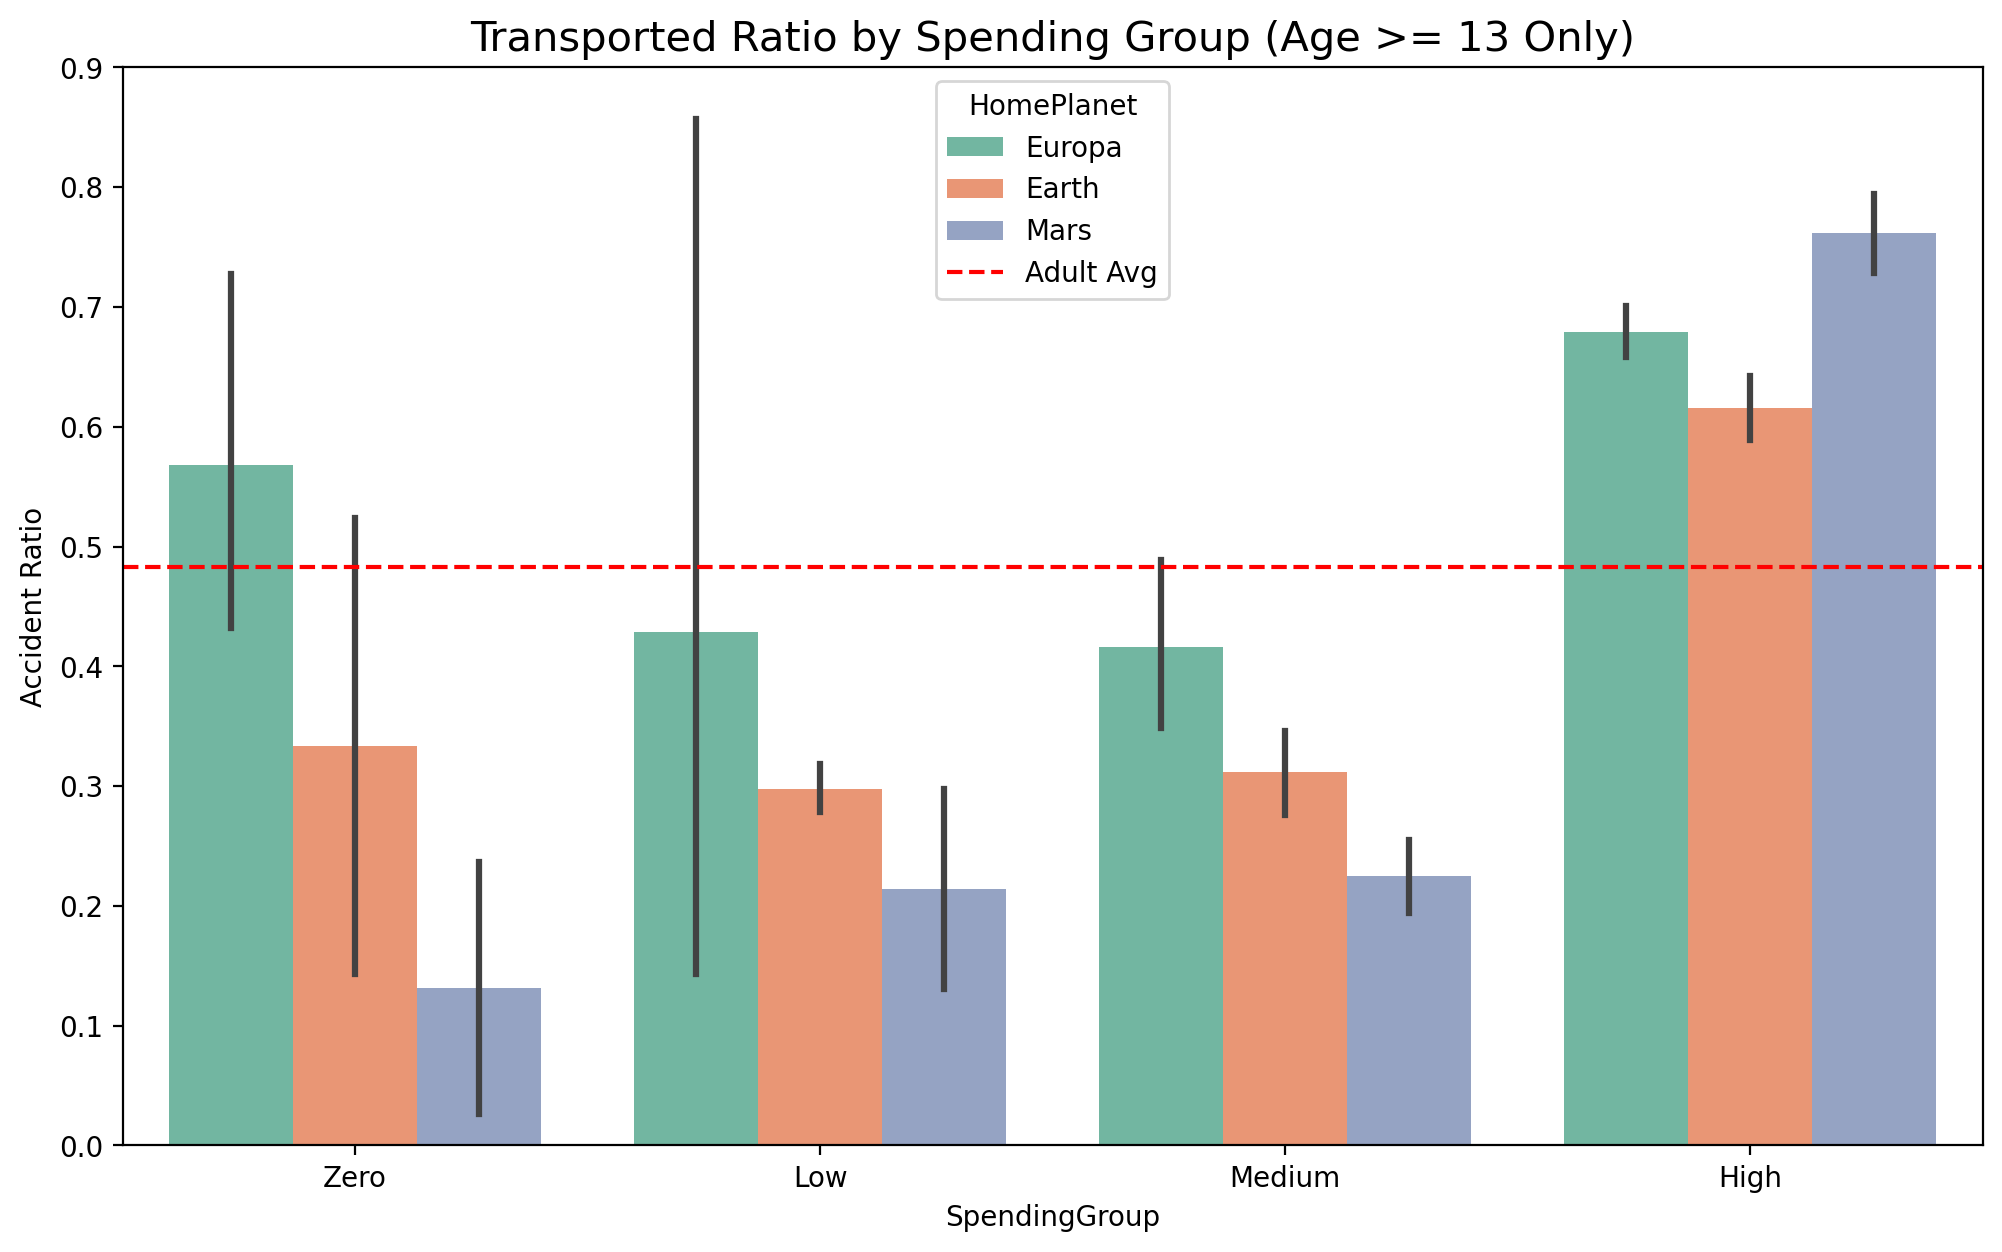

In [28]:
plt.figure(figsize=(12, 7))

# 어린이를 제외한 성인 그룹의 소비 그룹별 사고율 시각화
sns.barplot(data=adults_df, 
            x='SpendingGroup', 
            y='Transported', 
            hue='HomePlanet', 
            order=['Zero', 'Low', 'Medium', 'High'],
            palette='Set2')

# 전체 성인 평균 사고율 선
plt.axhline(adults_df['Transported'].mean(), color='red', linestyle='--', label='Adult Avg')

plt.title('Transported Ratio by Spending Group (Age >= 13 Only)', size=15)
plt.ylabel('Accident Ratio')
plt.legend(title='HomePlanet')
plt.show()

### 출신행성을 추가하니 모든 그룹에서 유로파출신들이 사고율이 높게 나타납니다.
### 가설로 세운 소비패턴과 다른 중요한 요소가 있는거 같습니다.

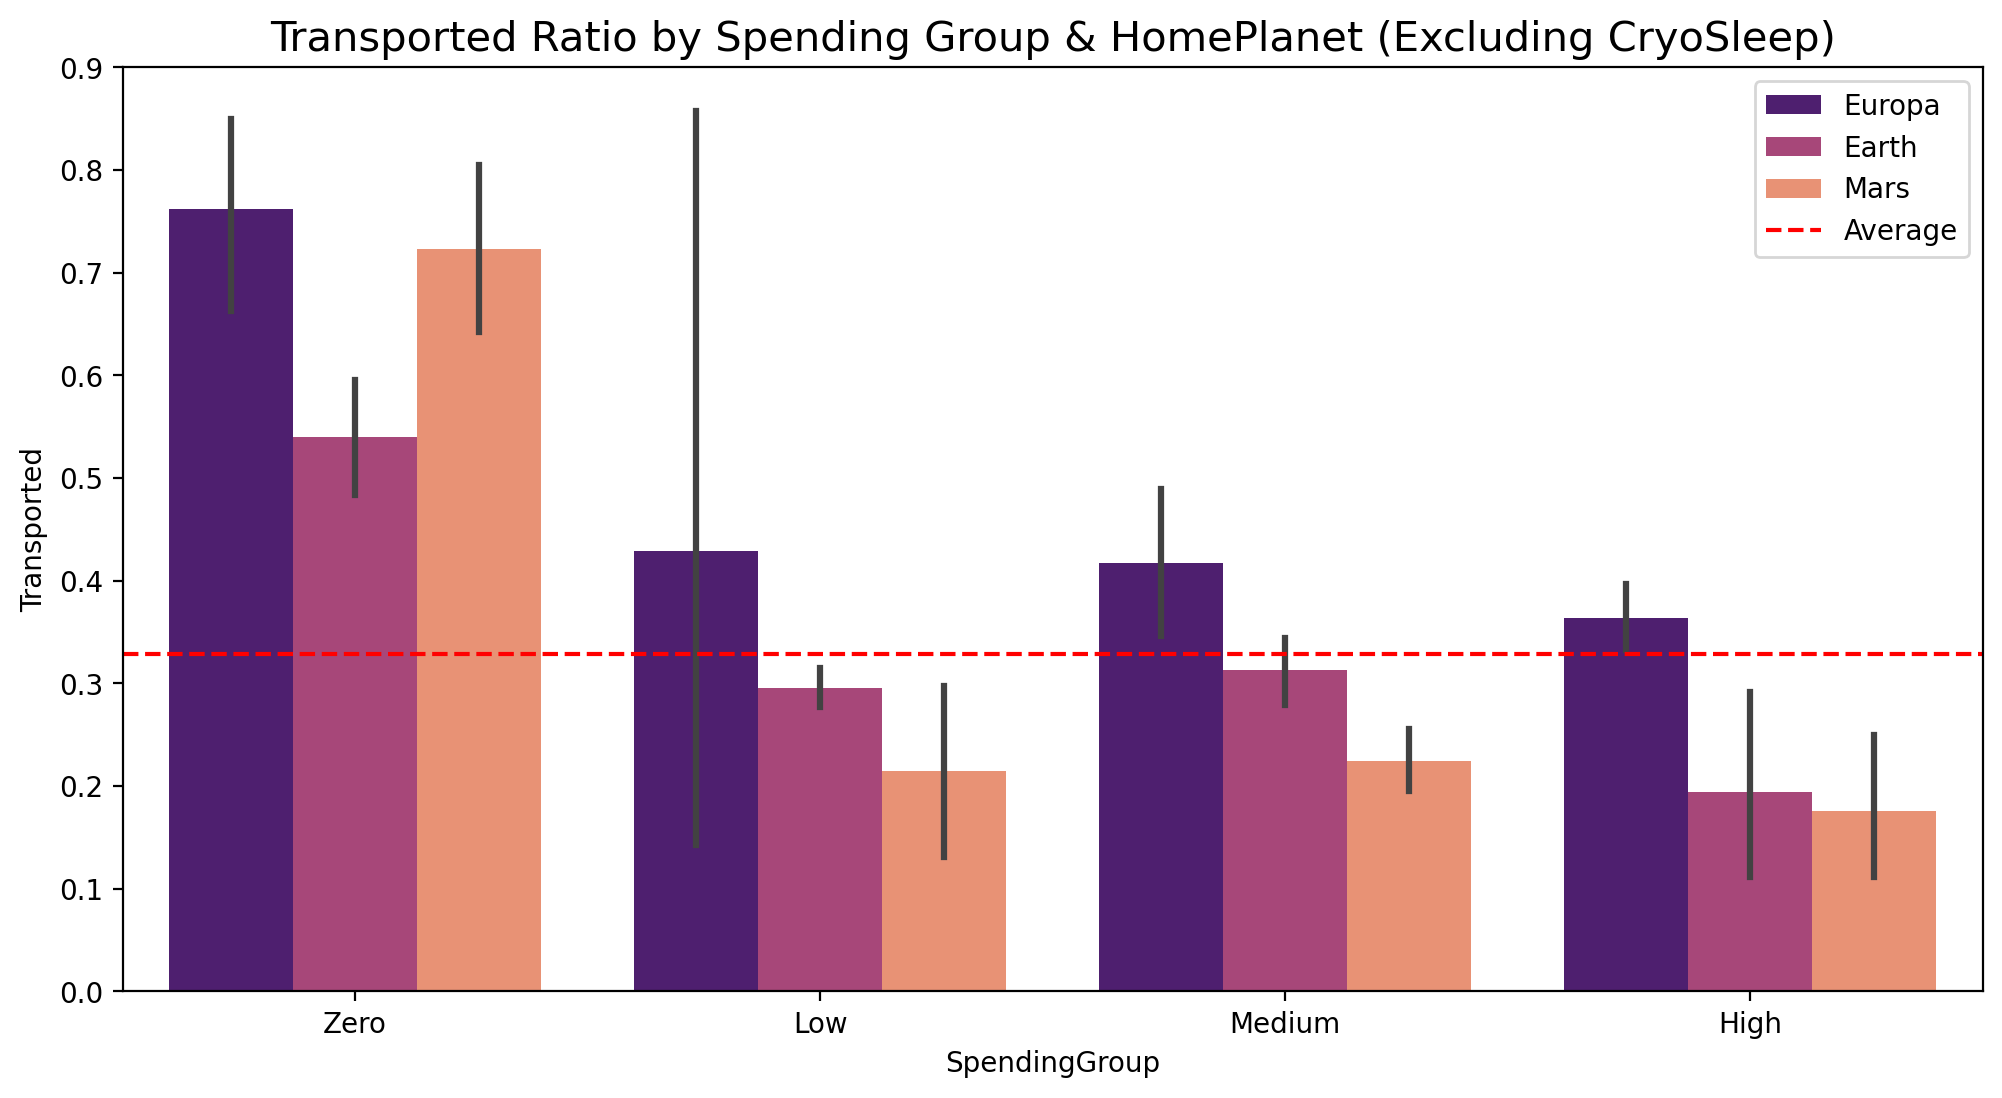

In [29]:
# 1. 동면하지 않는 승객만 필터링
active_passengers = train[train['CryoSleep'] == False].copy()

# 2. 시각화: 소비 그룹별 사고율을 보되, '출신 행성'별로 나누어 보기
plt.figure(figsize=(12, 6))

sns.barplot(data=active_passengers, 
            x='SpendingGroup', 
            y='Transported', 
            hue='HomePlanet', # 행성별로 나누어 보면 정체가 드러납니다!
            order=['Zero', 'Low', 'Medium', 'High'],
            palette='magma')

plt.title('Transported Ratio by Spending Group & HomePlanet (Excluding CryoSleep)', size=15)
plt.axhline(active_passengers['Transported'].mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.show()

### 가설3: 물리적 위치인 덱크의 위치에 따라 사고율이 크게 차이가 난다.
- 유로파 출신이 주로 머무는 구역과 사고에서 멀리 떨어져서 안전한 지역이 극명히 나눠질 것이다.

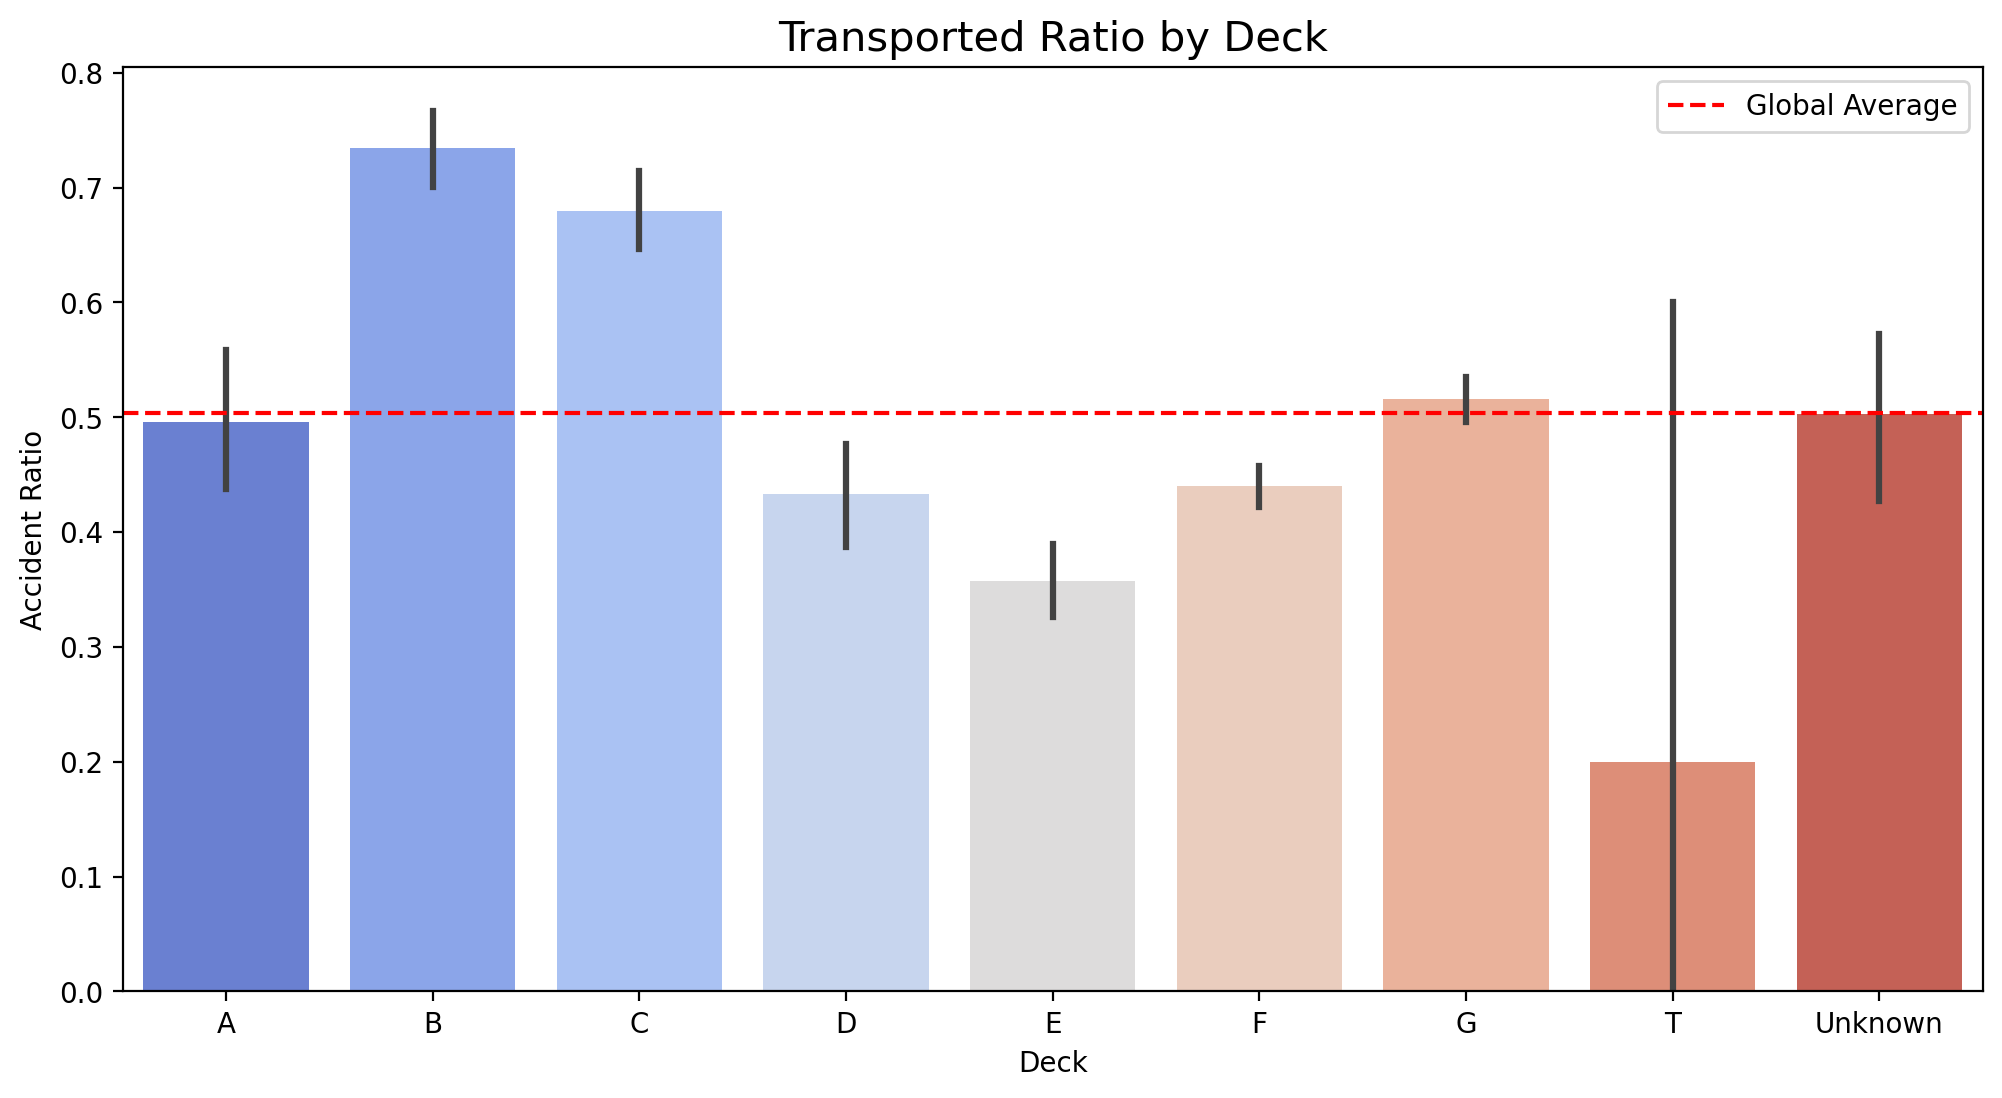

In [30]:
# 1. Cabin에서 Deck 정보 추출 (결측치는 'Unknown'으로 처리)
train['Deck'] = train['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'Unknown')

# 2. 데크별 사고율 시각화
plt.figure(figsize=(12, 6))

# 데크 순서 정렬 (A부터 G, 그리고 T와 Unknown)
deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'Unknown']

sns.barplot(data=train, x='Deck', y='Transported', order=deck_order, palette='coolwarm')

# 전체 평균 사고율 표시
plt.axhline(train['Transported'].mean(), color='red', linestyle='--', label='Global Average')

plt.title('Transported Ratio by Deck', size=15)
plt.ylabel('Accident Ratio')
plt.legend()
plt.show()

B,C 구역이 평균보다 높은 사고율이 나타났고 T,E구역은 오히려 사고율이 현저히 낮게 나타났습니다.

In [31]:
# 데크별 총 소비액의 중앙값 확인
deck_spend = train.groupby('Deck')['TotalSpending'].median().reindex(deck_order)
print("--- 데크별 소비액 중앙값 ---")
print(deck_spend)

--- 데크별 소비액 중앙값 ---
Deck
A          3759.5
B          5131.0
C          5760.0
D          2538.0
E           994.0
F           902.0
G           785.0
T          5287.5
Unknown    1240.5
Name: TotalSpending, dtype: float64


t구역은 소비액은 높은데 사고율이 낮군요! 특이 케이스네요.

In [32]:
# 1. T구역 거주자들의 상세 프로필 확인
t_deck_passengers = train[train['Deck'] == 'T']

print(f"T구역 총 인원: {len(t_deck_passengers)}명")
print("\n--- T구역 승객 상세 정보 ---")
print(t_deck_passengers[['HomePlanet', 'CryoSleep', 'TotalSpending', 'Transported']])

# 2. T구역과 다른 구역의 인원수 비교 (왜도 확인용)
print("\n--- 데크별 거주 인원수 ---")
print(train['Deck'].value_counts())

T구역 총 인원: 5명

--- T구역 승객 상세 정보 ---
     HomePlanet CryoSleep  TotalSpending  Transported
1004        NaN     False         1817.0        False
2254     Europa     False         7411.0        False
2734     Europa     False         7412.0        False
2763     Europa     False         3164.0         True
4565     Europa       NaN            NaN        False

--- 데크별 거주 인원수 ---
Deck
F          2794
G          2559
E           876
B           779
C           747
D           478
A           256
Unknown     199
T             5
Name: count, dtype: int64


단 5명만 있었습니다.   
포트와 스타보드에 따라 사고율이 달라지는 살펴봅시다.

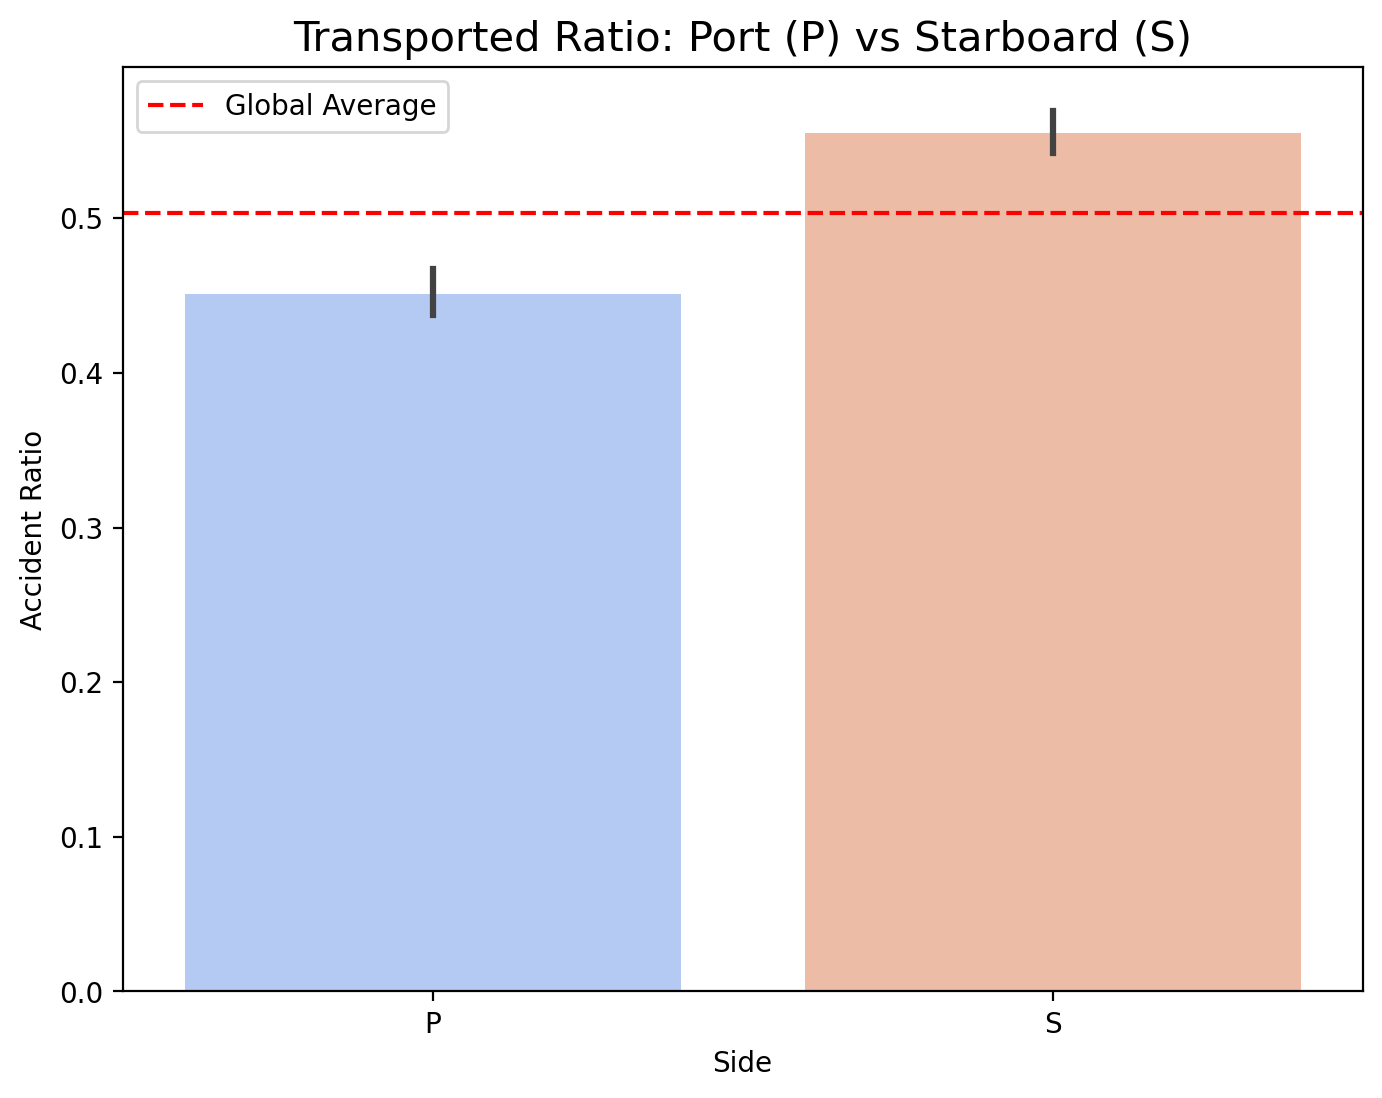

--- 좌현/우현별 사고 발생 인원 및 비율 ---
         count      mean
Side                    
P         4206  0.451260
S         4288  0.555037
Unknown    199  0.502513


In [33]:
# 1. Cabin에서 Side 정보 추출 (P 또는 S)
train['Side'] = train['Cabin'].apply(lambda x: str(x)[-1] if pd.notnull(x) and '/' in str(x) else 'Unknown')

# 2. 좌현/우현별 사고율 시각화
plt.figure(figsize=(8, 6))
sns.barplot(data=train[train['Side'] != 'Unknown'], x='Side', y='Transported', palette='coolwarm')

# 전체 평균선 표시
plt.axhline(train['Transported'].mean(), color='red', linestyle='--', label='Global Average')

plt.title('Transported Ratio: Port (P) vs Starboard (S)', size=15)
plt.ylabel('Accident Ratio')
plt.legend()
plt.show()

# 3. 수치로 정확히 확인
print("--- 좌현/우현별 사고 발생 인원 및 비율 ---")
side_report = train.groupby('Side')['Transported'].agg(['count', 'mean'])
print(side_report)

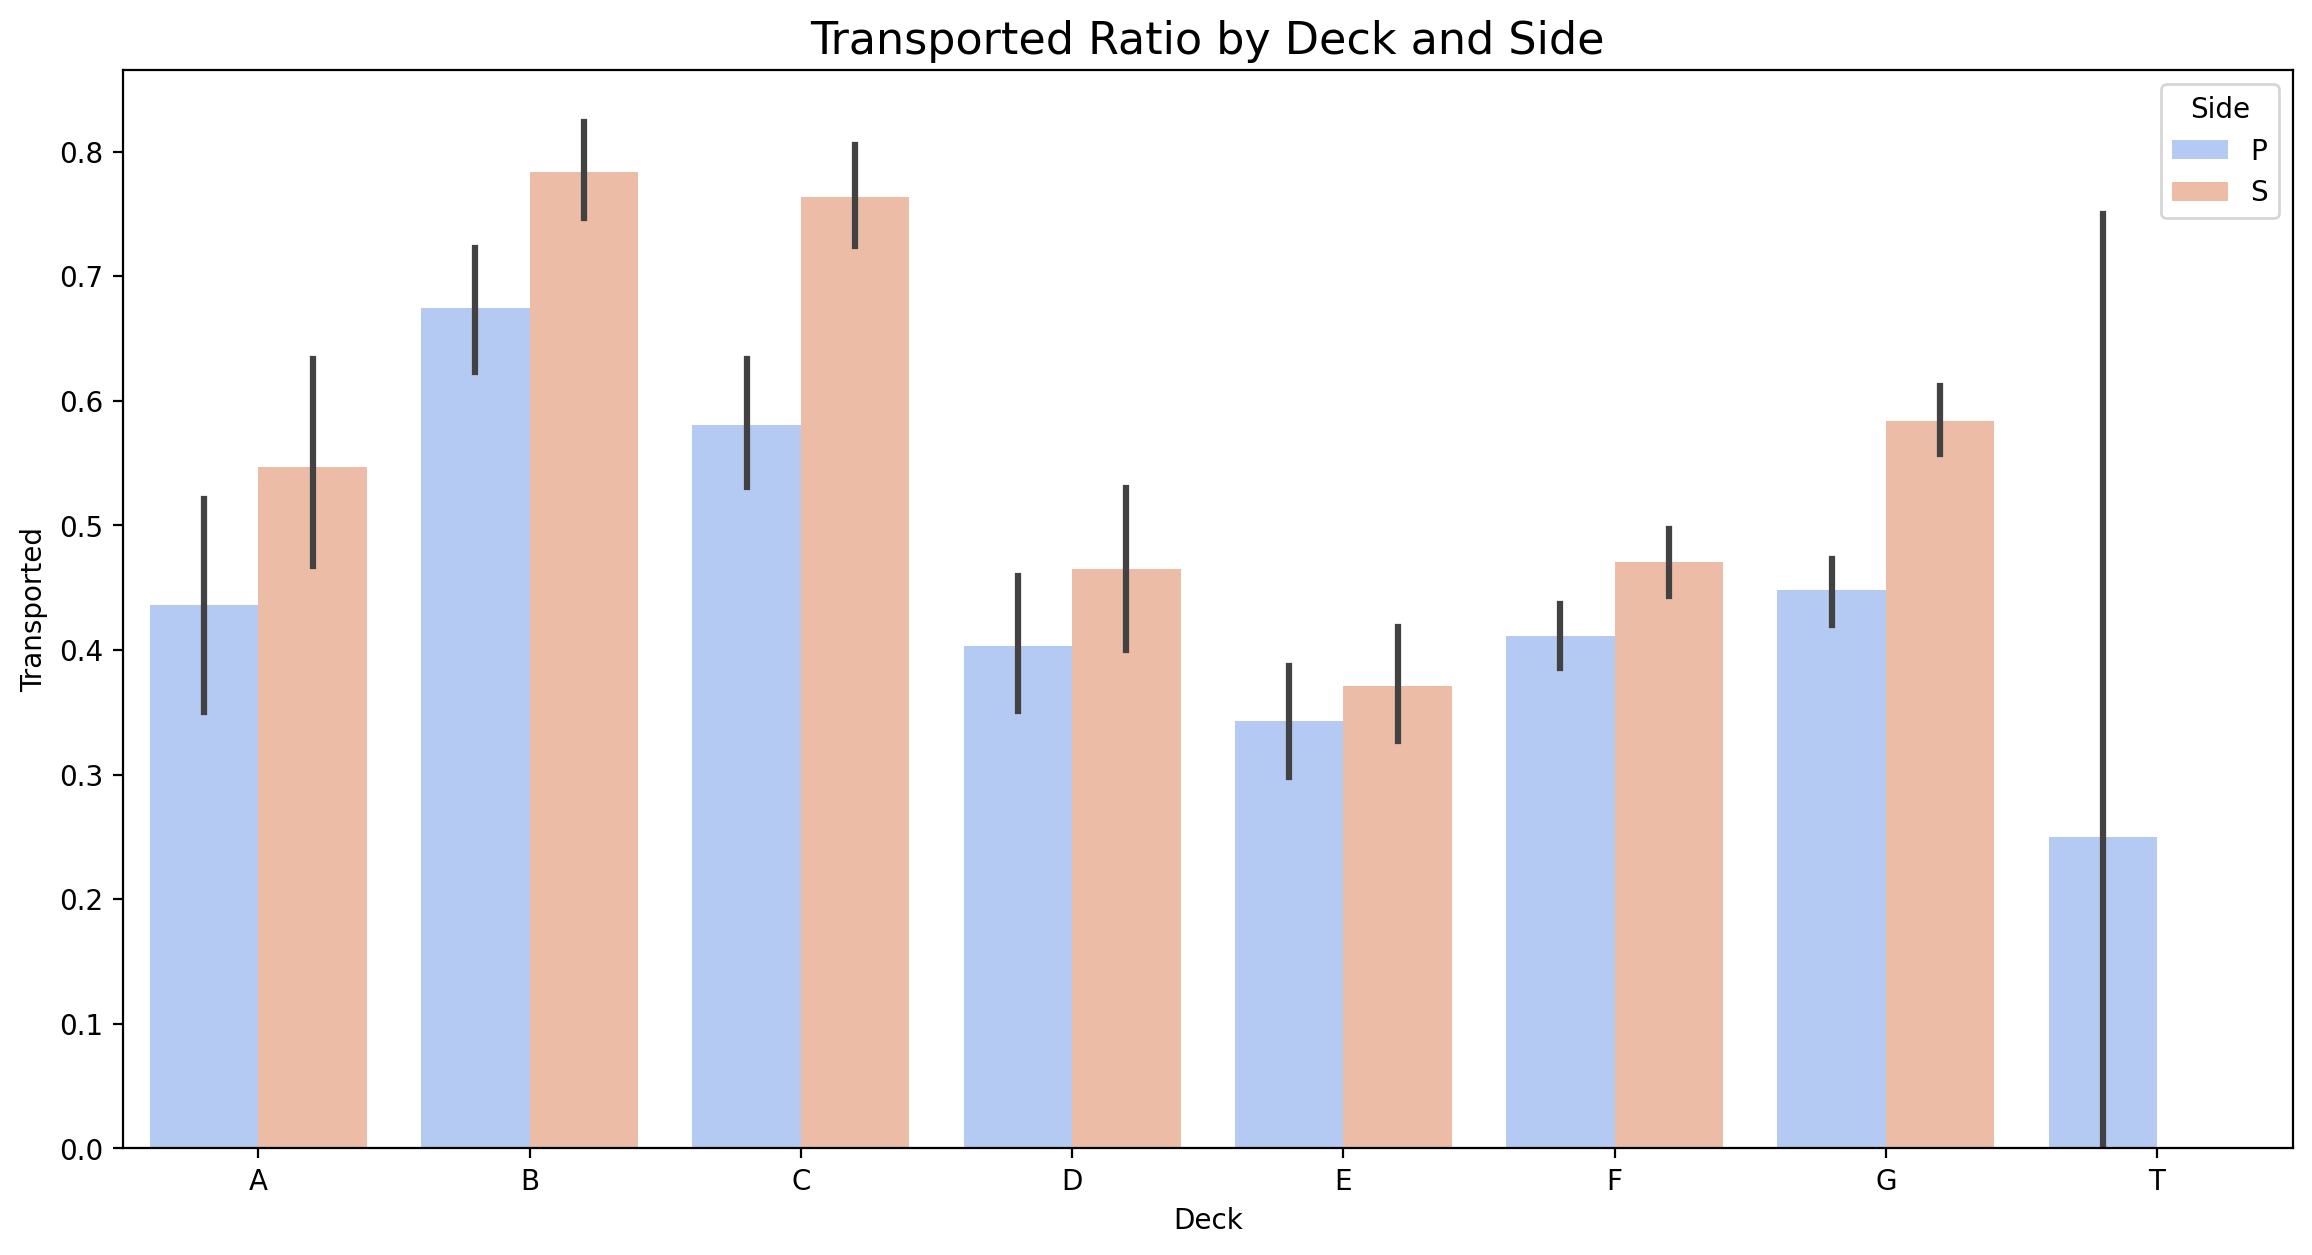

In [34]:
# 데크별 좌/우현 사고율 교차 분석
plt.figure(figsize=(14, 7))
sns.barplot(data=train[train['Side'] != 'Unknown'], x='Deck', y='Transported', hue='Side', 
            order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'], palette='coolwarm')

plt.title('Transported Ratio by Deck and Side', size=16)
plt.show()

### B,C구역 스타보드에서 가장 높은 사고율이 나타났습니다.

## 3. 피쳐 엔지니어링
- 어린이그룹은 사고율이 높기 때문에 특별한 그룹으로 지정
- 유로파 행성 출신은 사고지점에 가깝기 때문에 위험도가 높은 대상으로 고려
- 포트보다 스타보드쪽에 있는 사람들이 더 위험했다.

결측치 채우기.

In [35]:
train.isnull().sum()

PassengerId         0
HomePlanet        201
CryoSleep         217
Cabin             199
Destination       182
Age               179
VIP               203
RoomService       181
FoodCourt         183
ShoppingMall      208
Spa               183
VRDeck            188
Name              200
Transported         0
TotalSpending    3254
SpendingGroup       0
AgeGroup          357
Deck                0
Side                0
dtype: int64

동면중인 사람과 어린이는 소비가 0인 사실을 알기에 소비 결측치를 채운다.

In [50]:
# 소비가 있는 사람은 동면 중이 아님 (False)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train.loc[(train['CryoSleep'].isnull()) & (train[exp_cols].sum(axis=1) > 0), 'CryoSleep'] = False

# 동면 중인 사람의 소비 결측치는 0으로 채움
for col in exp_cols:
    train.loc[(train[col].isnull()) & (train['CryoSleep'] == True), col] = 0

# 어린이(Age < 13)의 소비 결측치는 0으로 채움
for col in exp_cols:
    train.loc[(train[col].isnull()) & (train['Age'] < 13), col] = 0

데크 정보를 통해 BCT 구역은 에우로파 G데크는 지구로 채운다.

In [51]:
# 1. Deck 정보를 이용해 HomePlanet 결측치 채우기
# B, C 데크는 에우로파 / G 데크는 지구일 확률이 압도적
train.loc[(train['HomePlanet'].isnull()) & (train['Deck'].isin(['B', 'C', 'T'])), 'HomePlanet'] = 'Europa'
train.loc[(train['HomePlanet'].isnull()) & (train['Deck'] == 'G'), 'HomePlanet'] = 'Earth'

# 2. 그룹별 중앙값으로 소비액 채우기
for col in exp_cols:
    train[col] = train[col].fillna(train.groupby(['HomePlanet', 'SpendingGroup'])[col].transform('median'))

같은 그룹일 경우 아이디와 모행성 결측치를 채운다.

In [42]:
# 같은 그룹(Id 앞 4자리) 내에서 결측치 채우기 (HomePlanet 예시)
train['GroupId'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
train['HomePlanet'] = train['HomePlanet'].fillna(train.groupby('GroupId')['HomePlanet'].transform('first'))

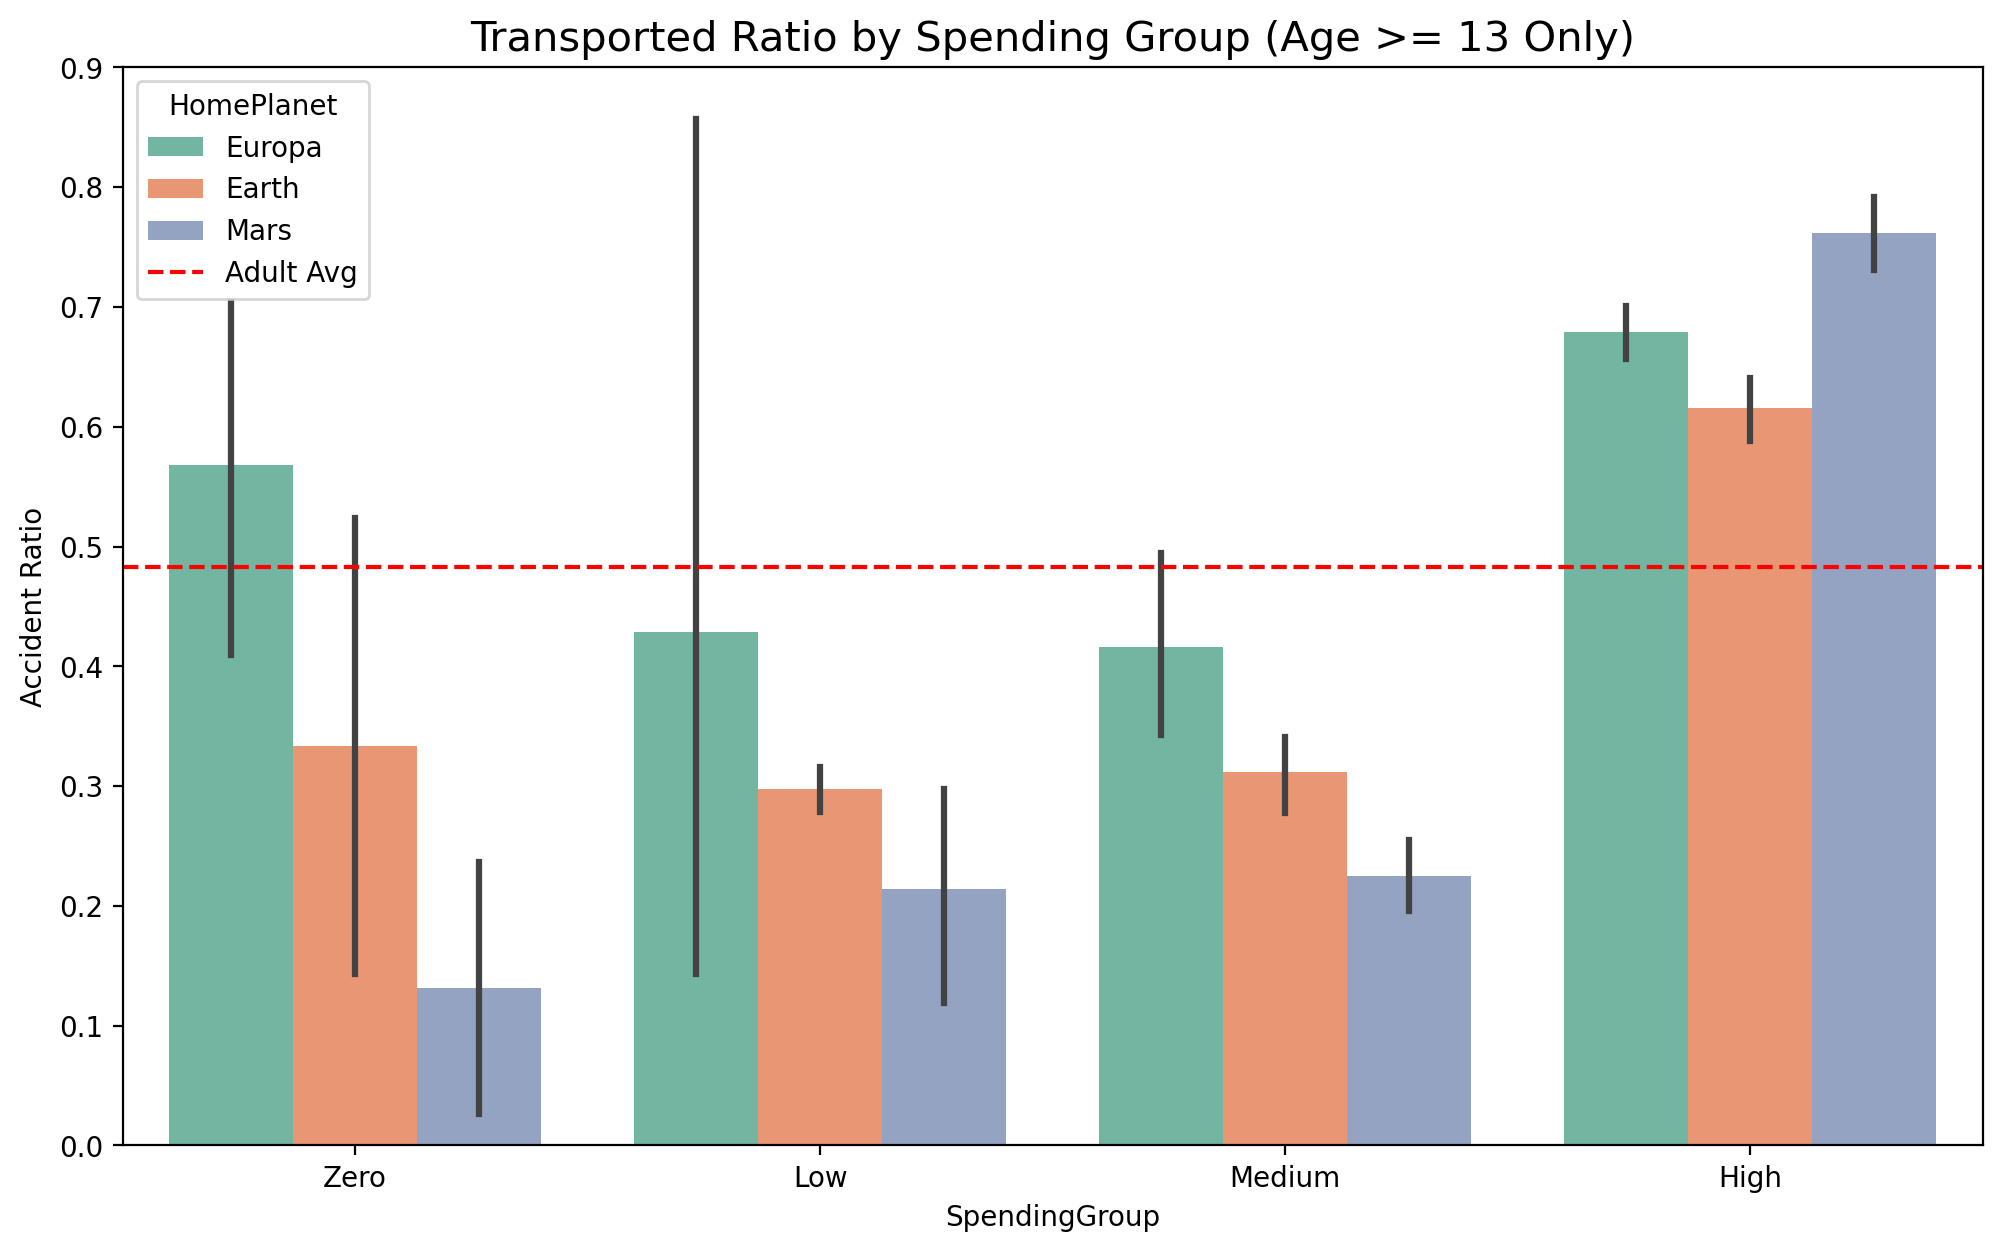

In [43]:
plt.figure(figsize=(12, 7))

# 어린이를 제외한 성인 그룹의 소비 그룹별 사고율 시각화
sns.barplot(data=adults_df, 
            x='SpendingGroup', 
            y='Transported', 
            hue='HomePlanet', 
            order=['Zero', 'Low', 'Medium', 'High'],
            palette='Set2')

# 전체 성인 평균 사고율 선
plt.axhline(adults_df['Transported'].mean(), color='red', linestyle='--', label='Adult Avg')

plt.title('Transported Ratio by Spending Group (Age >= 13 Only)', size=15)
plt.ylabel('Accident Ratio')
plt.legend(title='HomePlanet')
plt.show()

In [44]:
# 1. 어린이 여부 플래그 (가장 중요)
train['IsChild'] = train['Age'] < 13

# 2. 나이대 그룹화 (Child, Teen, Adult, Elderly)
train['AgeGroup'] = pd.cut(train['Age'], bins=[-1, 12, 18, 60, 100], 
                           labels=['Child', 'Teen', 'Adult', 'Elderly'])

# 3. 어린이 + 행성 조합 (에우로파 어린이는 특히 위험했을 수 있음)
train['Child_HomePlanet'] = train['HomePlanet'] + '_' + train['IsChild'].astype(str)

# 4. '동면하지 않는 어린이' 그룹
# (동면 중인 어린이는 동면실 위치에 영향을 받지만, 깨어있는 어린이는 대피 시 보호를 받았을 가능성)
train['ActiveChild'] = (train['Age'] < 13) & (train['CryoSleep'] == False)

In [45]:
# 1. '최고 위험 구역' 피처 생성
# B, C 데크이면서 우현(S)인 경우를 별도로 표시
train['Is_Ground_Zero'] = (train['Deck'].isin(['B', 'C'])) & (train['Side'] == 'S')

# 2. 데크와 측면을 결합한 상세 위치 정보
# 수정된 코드
train['Deck_Side'] = train['Deck'].astype(str) + '_' + train['Side'].astype(str)

# 3. 위치 기반 사고 확률(Target Encoding)
# 각 구역별 실제 사고율을 수치로 변환하여 모델에 전달
deck_side_risk = train.groupby(['Deck', 'Side'])['Transported'].mean().to_dict()
train['Location_Risk_Score'] = train.set_index(['Deck', 'Side']).index.map(deck_side_risk)

피쳐 엔지니어링으로 새로운 특성들 추가. 다시 결측치 확인

In [52]:
train.isnull().sum()

PassengerId              0
HomePlanet              64
CryoSleep               98
Cabin                    0
Destination            182
Age                      0
VIP                    203
RoomService              0
FoodCourt                0
ShoppingMall             0
Spa                      0
VRDeck                   0
Name                   200
Transported              0
TotalSpending            0
SpendingGroup            0
AgeGroup               179
Deck                     0
Side                     0
GroupId                  0
IsChild                  0
Child_HomePlanet        64
ActiveChild              0
Is_Ground_Zero           0
Deck_Side                0
Location_Risk_Score      0
dtype: int64

In [47]:
# 1. 같은 그룹 내에서 다른 가족의 Cabin 정보를 가져와서 채우기
train['Cabin'] = train['Cabin'].fillna(train.groupby('GroupId')['Cabin'].transform('first'))

# 2. 그래도 남은 결측치는 'Unknown'으로 처리 (혼자 온 승객 등)
train['Cabin'] = train['Cabin'].fillna('Unknown')

# 3. Cabin이 채워졌으니, Deck과 Side도 다시 업데이트 (이게 핵심!)
train['Deck'] = train['Cabin'].apply(lambda x: str(x)[0] if x != 'Unknown' else 'Unknown')
train['Side'] = train['Cabin'].apply(lambda x: str(x)[-1] if x != 'Unknown' else 'Unknown')

In [48]:
# 1. 먼저 TotalSpending의 결측치를 0으로 해결해야 합니다 (이전 단계 복습)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in exp_cols:
    train[col] = train[col].fillna(0)
train['TotalSpending'] = train[exp_cols].sum(axis=1)

# 2. 지출이 0원인 그룹과 지출이 있는 그룹의 나이 중앙값을 각각 구하기
zero_spend_age = train[train['TotalSpending'] == 0]['Age'].median()
positive_spend_age = train[train['TotalSpending'] > 0]['Age'].median()

# 3. 조건에 맞춰 결측치 채우기
train.loc[(train['Age'].isnull()) & (train['TotalSpending'] == 0), 'Age'] = zero_spend_age
train.loc[(train['Age'].isnull()) & (train['TotalSpending'] > 0), 'Age'] = positive_spend_age

In [53]:
train.isnull().sum()

PassengerId              0
HomePlanet              64
CryoSleep               98
Cabin                    0
Destination            182
Age                      0
VIP                    203
RoomService              0
FoodCourt                0
ShoppingMall             0
Spa                      0
VRDeck                   0
Name                   200
Transported              0
TotalSpending            0
SpendingGroup            0
AgeGroup               179
Deck                     0
Side                     0
GroupId                  0
IsChild                  0
Child_HomePlanet        64
ActiveChild              0
Is_Ground_Zero           0
Deck_Side                0
Location_Risk_Score      0
dtype: int64

In [54]:
from sklearn.preprocessing import LabelEncoder

# 인코딩할 컬럼들
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'AgeGroup', 'Child_HomePlanet']

for col in cat_cols:
    le = LabelEncoder()
    # 결측치가 이미 채워졌다고 가정하고 실행
    train[col] = le.fit_transform(train[col].astype(str))

# 학습에 사용할 최종 특성 선택
features = ['HomePlanet', 'CryoSleep', 'Age', 'IsChild', 'AgeGroup', 
            'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending',
            'Deck', 'Side', 'Is_Ground_Zero', 'Child_HomePlanet']

X = train[features]
y = train['Transported']

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 생성 및 학습
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 예측 및 성능 확인
preds = rf_model.predict(X_valid)
print(f"최종 모델 정확도: {accuracy_score(y_valid, preds):.4f}")

최종 모델 정확도: 0.7964


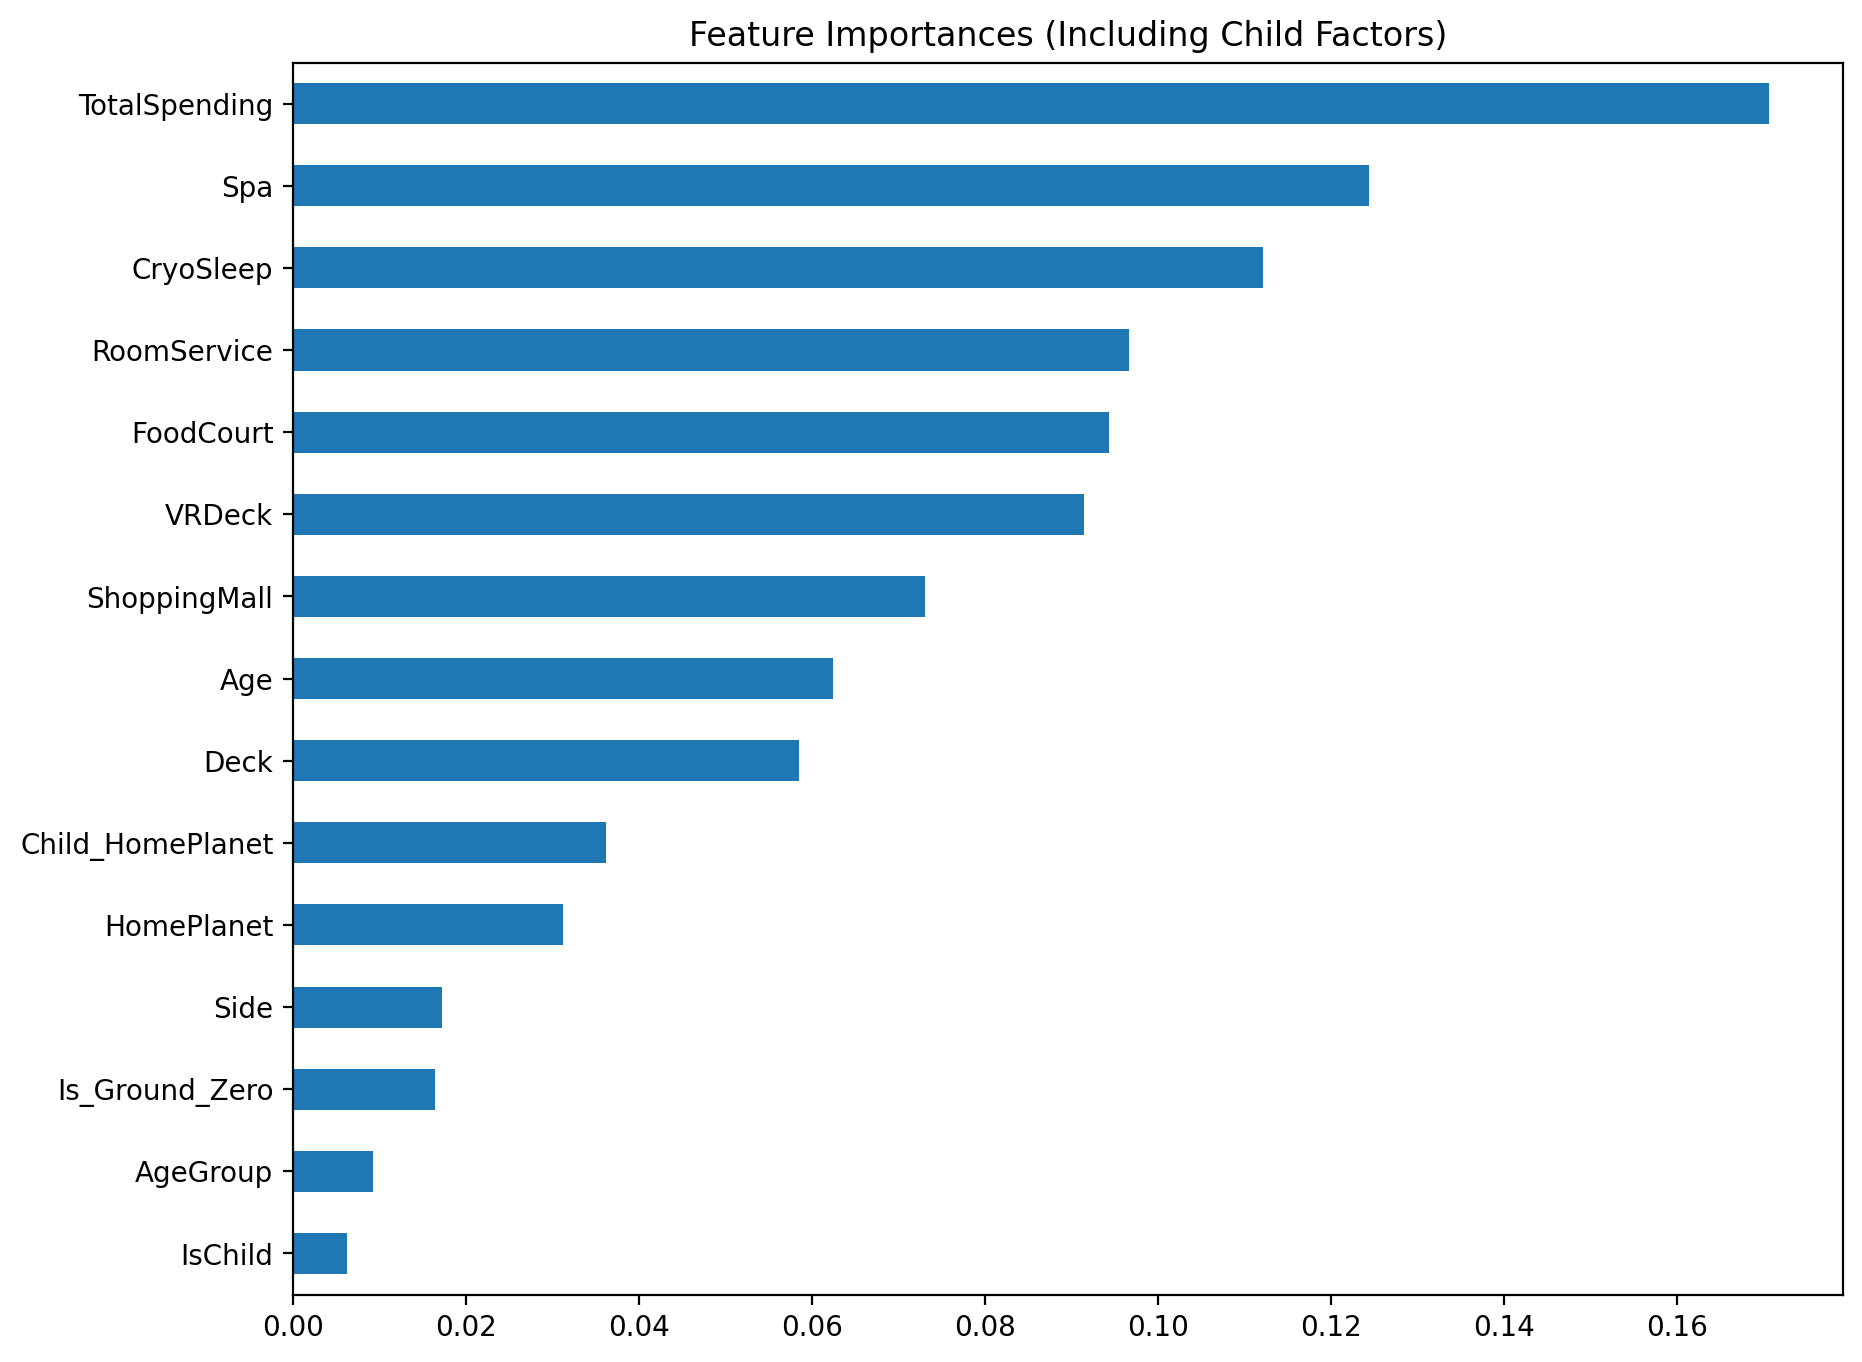

In [56]:
import matplotlib.pyplot as plt

# 특성 중요도 시각화
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importances (Including Child Factors)')
plt.show()

모델 예측 결과 0.7964 입니다. 
### 모델 개선을 위해 할일
- 하이퍼 파라미터 조정
- 모델 변화

In [58]:
from xgboost import XGBClassifier

# 2. 모델 생성 (하이퍼파라미터를 조금 정밀하게 설정)
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# 3. 학습 및 검증
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_valid)
print(f"XGBoost 최종 정확도: {accuracy_score(y_valid, xgb_preds):.4f}")

XGBoost 최종 정확도: 0.7976


In [48]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [67]:
# 2. 모델 생성 (하이퍼파라미터를 조금 정밀하게 설정)
xgb = XGBClassifier(
    n_estimators=550,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# 3. 학습 및 검증
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_valid)
print(f"XGBoost 최종 정확도: {accuracy_score(y_valid, xgb_preds):.4f}")

XGBoost 최종 정확도: 0.7993


In [78]:
# 1. 지출 관련 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 결측치를 0으로 임시 대체하고 총 지출(TotalSpending) 계산
test['TotalSpending'] = test[exp_cols].fillna(0).sum(axis=1)

test['Side'] = test['Cabin'].apply(lambda x: str(x)[-1] if pd.notnull(x) and '/' in str(x) else 'Unknown')

# 소비가 있는 사람은 동면 중이 아님 (False)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test.loc[(test['CryoSleep'].isnull()) & (test[exp_cols].sum(axis=1) > 0), 'CryoSleep'] = False

# 동면 중인 사람의 소비 결측치는 0으로 채움
for col in exp_cols:
    test.loc[(train[col].isnull()) & (test['CryoSleep'] == True), col] = 0

# 어린이(Age < 13)의 소비 결측치는 0으로 채움
for col in exp_cols:
    test.loc[(train[col].isnull()) & (test['Age'] < 13), col] = 0

    # 1. 같은 그룹 내에서 다른 가족의 Cabin 정보를 가져와서 채우기
test['Cabin'] = test['Cabin'].fillna(test.groupby('GroupId')['Cabin'].transform('first'))

# 2. 그래도 남은 결측치는 'Unknown'으로 처리 (혼자 온 승객 등)
test['Cabin'] = test['Cabin'].fillna('Unknown')

# 3. Cabin이 채워졌으니, Deck과 Side도 다시 업데이트 (이게 핵심!)
test['Deck'] = test['Cabin'].apply(lambda x: str(x)[0] if x != 'Unknown' else 'Unknown')
test['Side'] = test['Cabin'].apply(lambda x: str(x)[-1] if x != 'Unknown' else 'Unknown')

# 1. '최고 위험 구역' 피처 생성
# B, C 데크이면서 우현(S)인 경우를 별도로 표시
test['Is_Ground_Zero'] = (test['Deck'].isin(['B', 'C'])) & (test['Side'] == 'S')

# 2. 데크와 측면을 결합한 상세 위치 정보
# 수정된 코드
test['Deck_Side'] = test['Deck'].astype(str) + '_' + test['Side'].astype(str)

# 3. 위치 기반 사고 확률(Target Encoding)
# 각 구역별 실제 사고율을 수치로 변환하여 모델에 전달
deck_side_risk = train.groupby(['Deck', 'Side'])['Transported'].mean().to_dict()
test['Location_Risk_Score'] = test.set_index(['Deck', 'Side']).index.map(deck_side_risk)
                                                                          # 1. Deck 정보를 이용해 HomePlanet 결측치 채우기
# B, C 데크는 에우로파 / G 데크는 지구일 확률이 압도적
test.loc[(test['HomePlanet'].isnull()) & (test['Deck'].isin(['B', 'C', 'T'])), 'HomePlanet'] = 'Europa'
test.loc[(test['HomePlanet'].isnull()) & (test['Deck'] == 'G'), 'HomePlanet'] = 'Earth'
# 2. 그룹별 중앙값으로 소비액 채우기
for col in exp_cols:
    test[col] = test[col].fillna(train.groupby(['HomePlanet', 'SpendingGroup'])[col].transform('median'))

    # 1. 먼저 TotalSpending의 결측치를 0으로 해결해야 합니다 (이전 단계 복습)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in exp_cols:
    test[col] = test[col].fillna(0)
test['TotalSpending'] = test[exp_cols].sum(axis=1)

# 2. 지출이 0원인 그룹과 지출이 있는 그룹의 나이 중앙값을 각각 구하기
zero_spend_age = test[test['TotalSpending'] == 0]['Age'].median()
positive_spend_age = test[test['TotalSpending'] > 0]['Age'].median()

# 3. 조건에 맞춰 결측치 채우기
test.loc[(test['Age'].isnull()) & (test['TotalSpending'] == 0), 'Age'] = zero_spend_age
test.loc[(test['Age'].isnull()) & (test['TotalSpending'] > 0), 'Age'] = positive_spend_age


In [79]:
# 1. IsChild 생성 (숫자형으로 변환)
test['IsChild'] = (test['Age'] < 13).astype(int)

# 2. Child_HomePlanet 생성 (모든 재료를 str로 강제 변환)
# 여기서 에러가 났을 확률이 높습니다. .astype(str)을 꼭 확인하세요!
test['Child_HomePlanet'] = (
    test['HomePlanet'].astype(str) + 
    "_" + 
    test['IsChild'].astype(str)
)

# 3. AgeGroup 생성 (숫자 라벨로 바로 할당)
test['AgeGroup'] = pd.cut(
    test['Age'], 
    bins=[-1, 12, 18, 35, 60, 100], 
    labels=[0, 1, 2, 3, 4]
).astype(int) # 에러 방지를 위해 정수형으로 고정

# 4. Is_Ground_Zero 생성 (불리언을 숫자로 변환)
test['Is_Ground_Zero'] = (
    ((test['Deck'] == 'B') | (test['Deck'] == 'C')) & 
    (test['Side'] == 'S')
).astype(int)

# 5. 모델이 요구하는 15개 피처 다시 뽑기
required_features = [
    'HomePlanet', 'CryoSleep', 'Age', 'IsChild', 'AgeGroup', 
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
    'TotalSpending', 'Deck', 'Side', 'Is_Ground_Zero', 'Child_HomePlanet'
]

# 6. 마지막으로 모든 글자 데이터를 숫자로 변환 (Label Encoding)
for col in required_features:
    if test[col].dtype == 'object' or test[col].dtype.name == 'category':
        test[col] = LabelEncoder().fit_transform(test[col].astype(str))

# 7. 예측 시도
X_test_15 = test[required_features].fillna(0)
final_preds = xgb.predict(X_test_15)

In [80]:
test.isnull().sum()

PassengerId               0
HomePlanet                0
CryoSleep                 0
Cabin                     0
Destination               0
Age                       0
VIP                       0
RoomService               0
FoodCourt                 0
ShoppingMall              0
Spa                       0
VRDeck                    0
Name                     94
GroupId                   0
Deck                      0
Side                      0
TotalSpending             0
IsChild                   0
Child_HomePlanet          0
Is_Ground_Zero            0
Deck_Side                 0
Location_Risk_Score    4277
AgeGroup                  0
dtype: int64

In [82]:
# 1. 모델이 "내놔!"라고 했던 15개 피처 리스트 (순서 중요)
final_features = [
    'HomePlanet', 'CryoSleep', 'Age', 'IsChild', 'AgeGroup', 
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
    'TotalSpending', 'Deck', 'Side', 'Is_Ground_Zero', 'Child_HomePlanet'
]

# 2. 테스트 데이터에 이름표만 붙여주기 (값은 이미 계산되어 있을 테니 선택만 합니다)
# 만약 IsChild 등이 없다면 아래 한 줄씩만 실행해서 만들어주세요.
# test['IsChild'] = (test['Age'] < 13).astype(int)
# test['Is_Ground_Zero'] = ((test['Deck'] == 'B') | (test['Deck'] == 'C')) & (test['Side'] == 'S')
# test['AgeGroup'] = pd.cut(test['Age'], bins=[-1, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(int)

# 3. 모델에게 딱 15개만 전달
X_test_final = test[final_features]

# 4. 문자열이 섞여있으면 안 되니 마지막으로 숫자 확인 (LabelEncoding)
from sklearn.preprocessing import LabelEncoder
for col in X_test_final.select_dtypes(include=['object', 'category']).columns:
    X_test_final[col] = LabelEncoder().fit_transform(X_test_final[col].astype(str))

# 5. 이제 진짜 예측!
final_preds = xgb.predict(X_test_final)

In [83]:
# 1. 15개 피처로 무장한 데이터로 모델 예측 (xgb 또는 rf_log)
# X_test_final은 아까 우리가 15개로 맞춘 그 데이터프레임입니다.
final_preds = xgb.predict(X_test_final)

# 2. 제출용 데이터프레임 만들기
# PassengerId는 원본 테스트 데이터의 것을 그대로 가져와야 합니다.
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": final_preds
})

# 3. [중요] Kaggle 양식에 맞춰 True/False로 변환
# 모델이 0, 1로 뱉었다면 반드시 불리언(Boolean) 타입으로 바꿔줘야 점수가 나옵니다.
submission['Transported'] = submission['Transported'].astype(bool)

# 4. 파일 저장 (index=False는 필수 중의 필수!)
submission.to_csv("submission.csv", index=False)

print("--- 🎉 submission.csv 파일 생성 완료! ---")
print("이제 이 파일을 다운로드해서 캐글에 제출하시면 됩니다.")

--- 🎉 submission.csv 파일 생성 완료! ---
이제 이 파일을 다운로드해서 캐글에 제출하시면 됩니다.


In [84]:
submission.shape

(4277, 2)

저는 정리정돈을 못하는 사람이 였습니다.  
학습용 데이터처리를 데스트용에도 해줘야 하는데 너무 늦게 시작 해서 머리가 아프고 엄청 꼬였습니다.